# Data Engineering Project

This project deals with the acquiring and integrating of static datasets about electric energy production and emissions in Australia for historic data and trend analysis.

## Importing necessary packages

In [1]:
import os
import io
import re
import math
import time
import pathlib
from typing import List, Dict, Any, Optional
from collections import defaultdict
from urllib.parse import urljoin

import requests
import urllib3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from requests_html import HTMLSession
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

import os, time, json
from tqdm import tqdm
from tqdm.auto import tqdm
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from geopy.point import Point
import folium

C:\Users\ivini\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\ivini\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\ivini\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Acquiring data from NGER website

In [2]:
BASE = "https://api.cer.gov.au/datahub-public/v1/api/ODataDataset/NGER/dataset"

DATASET_IDS = [f"ID00{i}" for i in range(75, 84)] + ["ID0243"]  # 0075–0083 + 0243

HEADERS = {
    "Accept": "application/json",
    "User-Agent": "nger-data-notebook/1.1"
}

In [3]:
# Send a GET request with basic retry/backoff for transient HTTP errors (429/5xx)
def _request(url: str, params=None, max_retry: int = 3):
    r = requests.get(url, params=params or {}, headers=HEADERS, timeout=30)
    retry = 0
    while r.status_code in (429, 500, 502, 503, 504) and retry < max_retry:
        time.sleep((retry + 1) * 1.5)
        r = requests.get(url, params=params or {}, headers=HEADERS, timeout=30)
        retry += 1
    r.raise_for_status()
    return r

In [4]:
# returns the first list of records from diverse API payload shapes.
def _extract_records(obj) -> List[Dict[str, Any]]:
    for key in ("value", "items", "results", "records"):
        if isinstance(obj, dict) and isinstance(obj.get(key), list):
            return obj[key]
    if isinstance(obj, list):
        return obj
    for v in (obj.values() if isinstance(obj, dict) else []):
        if isinstance(v, list):
            return v
    return []

In [5]:
# Fetch the OData 'next' URL from a response dict, handling common key variants.
def _get_next_link(d: Dict[str, Any]) -> Optional[str]:
    for k in ("@odata.nextLink", "odata.nextLink", "nextLink", "next"):
        v = d.get(k) if isinstance(d, dict) else None
        if isinstance(v, str) and v:
            return v
    return None

In [6]:
# Download one NGER dataset via OData pagination/fallback, normalize schema, and add source columns.
def fetch_one_dataset(dataset_id: str,
                      page_size: int = 5000,
                      max_pages: int = 500,
                      sleep_sec: float = 0.2,
                      add_dataset_id: bool = True,
                      add_source_api: bool = False) -> pd.DataFrame:
    base_url = f"{BASE}/{dataset_id}"
    rows: List[Dict[str, Any]] = []
    try:
        url, params, pages = base_url, {}, 0
        while True:
            data = _request(url, params).json()
            recs = _extract_records(data)
            if recs:
                rows.extend(recs)
            nxt = _get_next_link(data)
            if nxt and pages < max_pages:
                url, params, pages = nxt, {}, pages + 1
                time.sleep(sleep_sec)
                continue
            break
    except requests.HTTPError:
        rows = []
    if not rows:
        skip, pages = 0, 0
        while True:
            data = _request(base_url, {"$top": str(page_size), "$skip": str(skip)}).json()
            recs = _extract_records(data)
            if not recs:
                break
            rows.extend(recs)
            if len(recs) < page_size or pages >= max_pages:
                break
            skip += page_size
            pages += 1
            time.sleep(sleep_sec)
    df = pd.json_normalize(rows) if rows else pd.DataFrame()
    df = normalize_nger_schema(df, canonical_only=True)
    if add_dataset_id:
        df.insert(0, "source_dataset_id", dataset_id)
    if add_source_api:
        df.insert(1, "source_api", base_url)
    return df

In [7]:
# Rename any year/reporting-like column to 'reporting_year' for consistency (no-op if none found).
def coalesce_year_column(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    year_like = [c for c in df.columns if re.search(r"(year|yr|reporting)", str(c), re.I)]
    for c in year_like:
        if any(k in c.lower() for k in ("report", "year", "yr")):
            return df.rename(columns={c: "reporting_year"})
    return df

In [8]:
# Unify column names and types across NGER yearly schemas
def normalize_nger_schema(df: pd.DataFrame, canonical_only: bool = True) -> pd.DataFrame:
    """
    Unify the fields of each year in NGER
    """
    if df.empty:
        return df
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    def _coalesce_first(frame: pd.DataFrame, candidates: list, numeric: bool = False) -> pd.Series:
        cols = [c for c in candidates if c in frame.columns and frame[c].notna().any()]
        if not cols:
            return pd.Series(np.nan if numeric else pd.NA, index=frame.index,
                             dtype=("float64" if numeric else "object"))
        tmp = frame[cols].copy()
        if numeric:
            for c in cols: tmp[c] = pd.to_numeric(tmp[c], errors="coerce")
            return tmp.bfill(axis=1).iloc[:, 0].astype("float64")
        return tmp.bfill(axis=1).iloc[:, 0].astype("object")

    def _pick_cols(frame: pd.DataFrame, must_contain: list[str]) -> list[str]:
        out = []
        for c in frame.columns:
            s = re.sub(r'[\s\W_]+', '', str(c).lower())
            if all(k in s for k in must_contain):
                out.append(c)
        return out

    out = pd.DataFrame(index=df.index)
  
    out["reporting_entity"] = _coalesce_first(
        df, ["reportingEntity", "reportingentity", "controllingcorporation", "Controlling Corporation"]
    )
    
    out["facility_name"] = _coalesce_first(df, ["facilityName", "facilityname", "Facility Name"])
    out["type"]          = _coalesce_first(df, ["type", "Type"])
    out["state"]         = _coalesce_first(df, ["state", "State"]).astype(str).str.strip().str.upper()

    out["electricity_production_gj"] = _coalesce_first(
        df, ["electricityProductionGJ", "electricityproductionGJ", "Electricity Production (GJ)"], numeric=True)
    out["electricity_production_mwh"] = _coalesce_first(
        df, ["electricityProductionMWh", "electricityProductionMwh", "electricityproductionMWh",
             "Electricity Production (Mwh)", "Electricity Production (MWh)"], numeric=True)
    mwh = out["electricity_production_mwh"]
    gj2mwh = out["electricity_production_gj"] / 3.6
    out["production_mwh_std"] = mwh.where(mwh.notna(), gj2mwh)

    out["scope1_tco2e"] = _coalesce_first(
        df, ["scope1tCO2e","totalscope1emissionstCO2e","Total Scope1 Emissions tCO2e","Scope 1 t CO2-e"], numeric=True)
    out["scope2_tco2e"] = _coalesce_first(
        df, ["scope2tCO2e","totalscope2emissionstCO2e","Total Scope2 Emissions tCO2e","Scope 2 t CO2-e"], numeric=True)
    out["total_emissions_tco2e"] = _coalesce_first(
        df, ["totalEmissions tCO2e","totalemissionstCO2e","totalEmissionsstCO2e","Total Emissions t CO2-e"], numeric=True)
    out["total_emissions_tco2e"] = out["total_emissions_tco2e"].fillna(out["scope1_tco2e"] + out["scope2_tco2e"])

    intensity_cols = _pick_cols(df, ["emission", "intensity", "mwh"])
    out["emission_intensity_t_per_mwh"] = _coalesce_first(df, intensity_cols, numeric=True)

    gc_raw  = _coalesce_first(df, ["gridConnected", "gridconnected", "gridConnected2", "Grid Connected"])
    gc_norm = gc_raw.astype("string").str.strip()

    gc_out = pd.Series("N/A", index=df.index, dtype="string")
    mask_on  = gc_norm.str.casefold().eq("on")
    mask_off = gc_norm.str.casefold().eq("off")
    gc_out.loc[mask_on]  = "On"
    gc_out.loc[mask_off] = "Off"

    out["grid_connected"] = gc_out
   
    out["grid"]         = _coalesce_first(df, ["grid", "Grid"])
    out["primary_fuel"] = _coalesce_first(df, ["primaryFuel", "primaryfuel", "Primary Fuel"])
    out["important_notes"] = _coalesce_first(df, ["importantNotes", "importantnotes", "Important Notes"])

    return out if canonical_only else pd.concat([df, out], axis=1)

In [9]:
frames = [fetch_one_dataset(dsid, add_dataset_id=True, add_source_api=False)
          for dsid in DATASET_IDS]
NGER_data = pd.concat(frames, ignore_index=True)
NGER_data = NGER_data.rename(columns={"state": "State"})
print(NGER_data.shape)
NGER_data.head(6)

(5942, 16)


,source_dataset_id,reporting_entity,facility_name,type,State,electricity_production_gj,electricity_production_mwh,production_mwh_std,scope1_tco2e,scope2_tco2e,total_emissions_tco2e,emission_intensity_t_per_mwh,grid_connected,grid,primary_fuel,important_notes
0,ID0075,ACCIONA ENERGY OCEANIA PTY LTD,Gunning Wind Farm,F,NSW,567719.0,157700.0,157700.0,19.0,293.0,312.0,0.00,On,NEM,Wind,N/A
1,ID0075,ACCIONA ENERGY OCEANIA PTY LTD,Royalla Solar Farm,F,ACT,213115.0,59199.0,59199.0,0.0,15.0,15.0,0.00,On,NEM,Solar,N/A
2,ID0075,ACCIONA ENERGY OCEANIA PTY LTD,Waubra Wind Farm,F,VIC,2461803.0,683834.0,683834.0,77.0,1144.0,1221.0,0.00,On,NEM,Wind,N/A
3,ID0075,ACCIONA ENERGY OCEANIA PTY LTD,Corporate Total,C,N/A,3242637.0,900733.0,900733.0,96.0,1452.0,1548.0,NaN,N/A,N/A,N/A,N/A
4,ID0075,AGL ENERGY LIMITED,Banimboola Hydro,F,VIC,137094.0,38082.0,38082.0,5.0,17.0,22.0,0.00,On,NEM,Hydro,N/A
5,ID0075,AGL ENERGY LIMITED,Bayswater Power Station,F,NSW,50275548.0,13965430.0,13965430.0,12253123.0,8306.0,12261429.0,0.88,On,NEM,Black Coal,N/A


## Pre-processing the NGER Data

In [10]:
NGER_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5942 entries, 0 to 5941
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   source_dataset_id             5942 non-null   object 
 1   reporting_entity              5942 non-null   object 
 2   facility_name                 5942 non-null   object 
 3   type                          5942 non-null   object 
 4   State                         5942 non-null   object 
 5   electricity_production_gj     5938 non-null   float64
 6   electricity_production_mwh    5938 non-null   float64
 7   production_mwh_std            5938 non-null   float64
 8   scope1_tco2e                  3871 non-null   float64
 9   scope2_tco2e                  3871 non-null   float64
 10  total_emissions_tco2e         3871 non-null   float64
 11  emission_intensity_t_per_mwh  4830 non-null   float64
 12  grid_connected                5942 non-null   string 
 13  gri

In [11]:
# Data Type Conversion
string_cols = [
    "source_dataset_id", "reporting_entity", "facility_name", 
    "type", "State", "grid_connected", "grid", 
    "primary_fuel", "important_notes"
]
NGER_data[string_cols] = NGER_data[string_cols].astype("string")


int_cols = [
    "electricity_production_gj", "electricity_production_mwh",
    "scope1_tco2e", "scope2_tco2e", "total_emissions_tco2e"
]
for c in int_cols:
    NGER_data[c] = pd.to_numeric(NGER_data[c], errors="coerce").astype("Int32")

In [12]:
# check value count
exclude_cols = {"source_dataset_id", "important_notes"}
cols_to_check = [c for c in NGER_data.columns if c not in exclude_cols]

for col in cols_to_check:
    print(f"\n=== {col} ===")
    print(NGER_data[col].value_counts(dropna=False).head(10)) 


=== reporting_entity ===
reporting_entity
POWER AND WATER CORPORATION                      461
HYDRO-ELECTRIC CORPORATION                       329
AGL ENERGY LIMITED                               313
CK WILLIAM AUSTRALIA HOLDINGS PTY LTD            308
LMS ENERGY PTY LTD                               261
ENERGY QUEENSLAND LIMITED                        245
ORIGIN ENERGY LIMITED                            197
ELECTRICITY GENERATION AND RETAIL CORPORATION    136
REGIONAL POWER CORPORATION                       129
SPIC PACIFIC ENERGY PTY LTD                      102
Name: count, dtype: Int64

=== facility_name ===
facility_name
Corporate Total               1056
Facility                        17
Daandine Power Station          14
Wivenhoe Power Station          11
Royalla Solar Farm              11
Bayswater Power Station         11
Kareeya Power Station           11
Barron Gorge Power Station      11
Vales Point Power Station       11
Waterloo Wind Farm              11
Name: count, d

In [13]:
cols = ["type", "State", "grid", "primary_fuel","important_notes"]

NGER_data[cols] = NGER_data[cols].apply(lambda s: s.astype("string").str.strip())

# Match: Empty string, hyphen (-), N/A, NA, <NA>, None, Nil
missing_pat = r"(?i)^(?:|-|n/?a|<na>|none|nil)$"   
NGER_data[cols] = NGER_data[cols].replace(missing_pat, pd.NA, regex=True)

# Standardize spacing, capitalization and common spelling
NGER_data["grid"] = (
    NGER_data["grid"]
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
      .str.title()
      .replace({
          "Off Grid": "Off-grid",
          "Dkis": "DKIS",
          "Nwis": "NWIS",
          "Mt Isa": "Mt Isa",
      })
)

NGER_data[cols] = NGER_data[cols].astype("string")
NGER_data["grid_connected"] = NGER_data["grid_connected"].replace("N/A", pd.NA)

In [14]:
#Check for any abnormal data, specifically situations where negative numbers occur.
num_cols = [
    "electricity_production_gj", "electricity_production_mwh", "production_mwh_std",
    "scope1_tco2e", "scope2_tco2e", "total_emissions_tco2e",
    "emission_intensity_t_per_mwh"
]

check_neg_zero = {}
for c in num_cols:
    col = pd.to_numeric(NGER_data[c], errors="coerce")
    check_neg_zero[c] = {
        "count_total": col.notna().sum(),
        "count_zero": (col == 0).sum(),
        "count_negative": (col < 0).sum(),
        "min_value": col.min(),
        "max_value": col.max(),
    }

check_df = pd.DataFrame(check_neg_zero).T
print(check_df)

                              count_total  count_zero  count_negative  \
electricity_production_gj          5938.0        71.0             0.0   
electricity_production_mwh         5938.0        72.0             0.0   
production_mwh_std                 5938.0        72.0             0.0   
scope1_tco2e                       3871.0       522.0             0.0   
scope2_tco2e                       3871.0      1462.0             0.0   
total_emissions_tco2e              3871.0       177.0             0.0   
emission_intensity_t_per_mwh       4830.0      1762.0             0.0   

                              min_value     max_value  
electricity_production_gj           0.0  8.189245e+08  
electricity_production_mwh          0.0  2.274790e+08  
production_mwh_std                  0.0  2.274790e+08  
scope1_tco2e                        0.0  1.432884e+08  
scope2_tco2e                        0.0  2.072018e+06  
total_emissions_tco2e               0.0  1.453605e+08  
emission_intensity_t_pe

In [15]:
NGER_data.isnull().sum().sort_values(ascending=False)

important_notes                 5905
scope1_tco2e                    2071
scope2_tco2e                    2071
total_emissions_tco2e           2071
emission_intensity_t_per_mwh    1112
State                           1062
grid_connected                  1062
grid                            1062
primary_fuel                    1062
type                               6
electricity_production_gj          4
electricity_production_mwh         4
production_mwh_std                 4
source_dataset_id                  0
reporting_entity                   0
facility_name                      0
dtype: int64

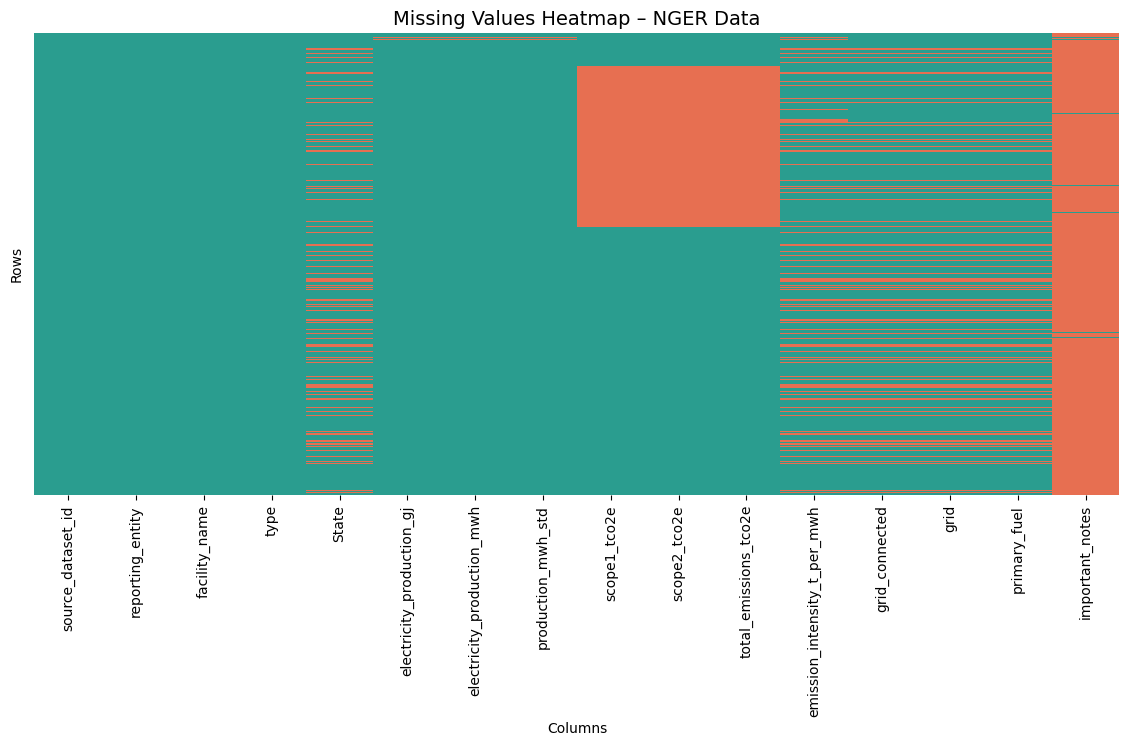

In [16]:
# Examine the distribution of missing values
plt.figure(figsize=(14,6))
sns.heatmap(
    NGER_data.isnull(),
    cbar=False,
    yticklabels=False,
    cmap=["#2a9d8f", "#e76f51"]
)
plt.title("Missing Values Heatmap – NGER Data", fontsize=14)
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

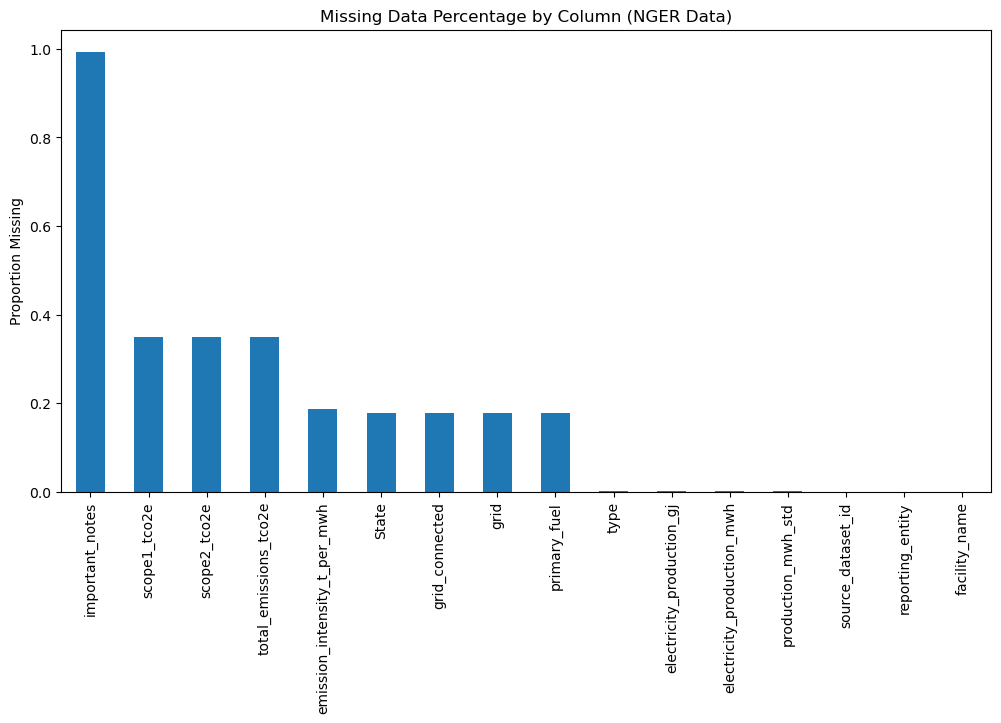

In [17]:
# Examine the distribution of missing values
missing_pct = (
    NGER_data
    .isnull()
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
missing_pct.plot(kind="bar")
plt.ylabel("Proportion Missing")
plt.title("Missing Data Percentage by Column (NGER Data)")
plt.show()

In [18]:
#Check the proportion of missing values
NGER_data.isnull().mean().round(3) * 100 

source_dataset_id                0.0
reporting_entity                 0.0
facility_name                    0.0
type                             0.1
State                           17.9
electricity_production_gj        0.1
electricity_production_mwh       0.1
production_mwh_std               0.1
scope1_tco2e                    34.9
scope2_tco2e                    34.9
total_emissions_tco2e           34.9
emission_intensity_t_per_mwh    18.7
grid_connected                  17.9
grid                            17.9
primary_fuel                    17.9
important_notes                 99.4
dtype: float64

In [19]:
NGER_data.head(5)

,source_dataset_id,reporting_entity,facility_name,type,State,electricity_production_gj,electricity_production_mwh,production_mwh_std,scope1_tco2e,scope2_tco2e,total_emissions_tco2e,emission_intensity_t_per_mwh,grid_connected,grid,primary_fuel,important_notes
0,ID0075,ACCIONA ENERGY OCEANIA PTY LTD,Gunning Wind Farm,F,NSW,567719,157700,157700.0,19,293,312,0.0,On,Nem,Wind,<NA>
1,ID0075,ACCIONA ENERGY OCEANIA PTY LTD,Royalla Solar Farm,F,ACT,213115,59199,59199.0,0,15,15,0.0,On,Nem,Solar,<NA>
2,ID0075,ACCIONA ENERGY OCEANIA PTY LTD,Waubra Wind Farm,F,VIC,2461803,683834,683834.0,77,1144,1221,0.0,On,Nem,Wind,<NA>
3,ID0075,ACCIONA ENERGY OCEANIA PTY LTD,Corporate Total,C,<NA>,3242637,900733,900733.0,96,1452,1548,NaN,<NA>,<NA>,<NA>,<NA>
4,ID0075,AGL ENERGY LIMITED,Banimboola Hydro,F,VIC,137094,38082,38082.0,5,17,22,0.0,On,Nem,Hydro,<NA>


## Acquiring the CER Data

In [20]:
URL = "https://cer.gov.au/markets/reports-and-data/large-scale-renewable-energy-data#supply-data"

opts = Options()
opts.add_argument("--headless=new")   
driver = webdriver.Chrome(options=opts)
driver.get(URL)

els = driver.find_elements(By.CSS_SELECTOR, 'a[href*="/document/power-stations-and-projects-"]')
hrefs = [urljoin(URL, e.get_attribute("href")) for e in els]
driver.quit()

seen = set()
hrefs = [u for u in hrefs if not (u in seen or seen.add(u))]
links = {k: next((u for u in hrefs if k in u.lower()), None)
         for k in ["accredited", "committed", "probable"]}

print(links) 

{'accredited': 'https://cer.gov.au/document/power-stations-and-projects-accredited', 'committed': 'https://cer.gov.au/document/power-stations-and-projects-committed', 'probable': 'https://cer.gov.au/document/power-stations-and-projects-probable'}


In [21]:
# get the three csv files
UA = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "text/csv,application/octet-stream,*/*",
    "Referer": "https://cer.gov.au/markets/reports-and-data/large-scale-renewable-energy-data#supply-data",
}

In [22]:
def fetch_csv(url: str) -> pd.DataFrame:
    r = requests.get(url, headers=UA, allow_redirects=True, timeout=60)
    r.raise_for_status()
    return pd.read_csv(io.BytesIO(r.content), encoding="cp1252")

In [23]:
CANON_MAP_CI = {
    "fuel source": "Fuel Source",
    "fuel source (s)": "Fuel Source",
    "mw capacity": "Mw Capacity",
    "installed capacity (mw)": "Mw Capacity",
    "state": "State",
    "postcode": "Postcode",
    "accreditation code": "Accreditation code",
    "accreditation start date": "Accreditation start date",
    "approval date": "Approval date",
    "committed date": "Committed Date (Month/Year)",
    "committed date (month/year)": "Committed Date (Month/Year)",
}

In [24]:
# Standardization of listed names
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    new_cols = []
    for c in df.columns:
        key = re.sub(r"\s+", " ", str(c)).strip().lower()
        key = key.replace("（", "(").replace("）", ")")
        new_cols.append(CANON_MAP_CI.get(key, c))  
    out = df.copy()
    out.columns = new_cols
    return out

In [25]:
def coalesce_duplicate_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    for col in pd.unique(df.columns):
        same = [c for c in df.columns if c == col]
        out[col] = df[same].bfill(axis=1).iloc[:, 0] if len(same) > 1 else df[same[0]]
    return out

In [26]:
def prepare_one(url: str, status: Optional[str] = None) -> pd.DataFrame:
    df = fetch_csv(url)
    df = normalize_columns(df)
    df = coalesce_duplicate_columns(df)
    
    if status is not None:
        df["status"] = status
    return df

In [27]:
df_accredited = prepare_one(links["accredited"], status=None)
df_committed = prepare_one(links["committed"], status="committed")
df_probable  = prepare_one(links["probable"],  status="probable")
df_committed_probable = pd.concat([df_committed, df_probable], ignore_index=True)

display(df_accredited.head())
display(df_committed_probable.head())

,Accreditation code,Power station name,State,Postcode,Mw Capacity,Fuel Source,Accreditation start date,Approval date
0,SRPXQLE8,"Laura Johnson Home, Townview - Solar w SGU - QLD",QLD,4825,0.227,Solar,15/10/2024,13/01/2025
1,SRPYNS39,Leppington - Solar - NSW,NSW,2179,0.732,Solar,22/11/2024,13/01/2025
2,SRPYNS58,Quakers Hillside Care Community - Solar w SGU ...,NSW,2763,0.200,Solar,19/12/2024,13/01/2025
3,SRPXVCN4,Rest Nominees - Solar wSGU - VIC,VIC,3008,0.119,Solar,20/09/2024,13/01/2025
4,SRPXQLF9,Retail First Mt Ommaney-Solar-QLD,QLD,4074,1.000,Solar,29/10/2024,13/01/2025


,Project Name,State,Mw Capacity,Fuel Source,Committed Date (Month/Year),status
0,East Rockingham Resource Recovery Facility,WA,29.0,Biomass,Dec-2019,committed
1,Mangalore Renewable Energy Project,VIC,5.0,Solar,Sep-2021,committed
2,Orange Community Renewable Energy Park,NSW,5.0,Solar,Jul-2022,committed
3,Moorebank Logistics Park,NSW,60.0,Solar,Sep-2022,committed
4,Kidston Pumped Hydro Storage Project,QLD,250.0,Hydro,Jul-2023,committed


## Pre-processing the CER Dataset

In [28]:
df_accredited.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Accreditation code        354 non-null    object 
 1   Power station name        354 non-null    object 
 2   State                     354 non-null    object 
 3   Postcode                  354 non-null    int64  
 4   Mw Capacity               354 non-null    float64
 5   Fuel Source               354 non-null    object 
 6   Accreditation start date  354 non-null    object 
 7   Approval date             354 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 22.2+ KB


In [29]:
# Data Type Conversion- for accredited df
str_cols = ["Accreditation code", "Power station name", "State", "Postcode", "Fuel Source"]
df_accredited[str_cols] = df_accredited[str_cols].astype("string")


date_cols = ["Accreditation start date", "Approval date"]
for col in date_cols:
    df_accredited[col] = pd.to_datetime(df_accredited[col], dayfirst=True, errors="coerce")

In [30]:
df_committed_probable.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Project Name                 97 non-null     object 
 1   State                        97 non-null     object 
 2   Mw Capacity                  97 non-null     float64
 3   Fuel Source                  97 non-null     object 
 4   Committed Date (Month/Year)  33 non-null     object 
 5   status                       97 non-null     object 
dtypes: float64(1), object(5)
memory usage: 4.7+ KB


In [31]:
# Data Type Conversion - for committed_probable df
str_cols = ["Project Name", "State", "Fuel Source", "status"]
df_committed_probable[str_cols] = df_committed_probable[str_cols].astype("string")

# convert Committed Date (Month/Year) to dateTime type ( and turn Dec-19 to 2019-12-01)
col = "Committed Date (Month/Year)"

dash_chars = r"[\u2010-\u2015\u2212\uFE58\uFE63\uFF0D]" 
cleaned = (
    df_committed_probable[col]
    .astype("string")
    .str.normalize("NFKC")
    .str.replace(dash_chars, "-", regex=True)
    .str.strip()
)

dt = pd.to_datetime(cleaned, format="%b-%y", errors="coerce")   # Dec-19
mask = dt.isna()
if mask.any():
    dt.loc[mask] = pd.to_datetime(cleaned[mask], format="%b-%Y", errors="coerce")  # Dec-2019
mask = dt.isna()
if mask.any():
    dt.loc[mask] = pd.to_datetime(cleaned[mask], errors="coerce")  

df_committed_probable[col] = dt

In [32]:
# use value count to check if there is an inconsistent value - for accredited df 
na_values = ["", " ", "-", "N/A", "<NA>", "na", "NA", "n/a"]


for col in df_accredited.columns:
    print(f"\n=== {col} ===")
    print(df_accredited[col].value_counts(dropna=False).head(10))


=== Accreditation code ===
Accreditation code
SRPXQLE8    1
SRPYNSB8    1
SRPXVCR8    1
SRPXVCS2    1
SRPXQLL5    1
SRPYNS80    1
SRPXQLL3    1
SRPXQLL2    1
SRPYNSA2    1
SRPVTA27    1
Name: count, dtype: Int64

=== Power station name ===
Power station name
Laura Johnson Home, Townview - Solar w SGU - QLD                1
Elements of Byron - Solar wSGU - NSW                            1
Greenlink 6 - Solar - VIC                                       1
GRAC - Solar w SGU - VIC                                        1
Domayne Maroochydore Homemaker - Solar w SGU - QLD              1
Culcairn Solar Farm - Solar - NSW                               1
House Power South Maroochydore Homemaker - Solar w SGU - QLD    1
House Power North Maroochydore Homemaker - Solar w SGU - QLD    1
AU254 M7 BH - Solar - NSW                                       1
Spreyton - Solar - TAS                                          1
Name: count, dtype: Int64

=== State ===
State
NSW    130
QLD     86
VIC     64


In [33]:
# use value count to check if there is an inconsistent value - for committed_probable df
for col in df_committed_probable.columns:
    print(f"\n=== {col} ===")
    print(df_committed_probable[col].value_counts(dropna=False).head(10))


=== Project Name ===
Project Name
East Rockingham Resource Recovery Facility    1
Eurimbula Solar Farm                          1
Moah Creek Wind Farm                          1
Middlebrook Solar Farm                        1
Merino Solar Farm                             1
Manilla Community Solar                       1
Majors Creek Solar Farm                       1
Lower Wonga Solar Farm project                1
Liverpool Range Wind Stage 1                  1
Lakeland Wind Farm                            1
Name: count, dtype: Int64

=== State ===
State
NSW    28
QLD    25
VIC    21
WA     11
SA      9
TAS     3
Name: count, dtype: Int64

=== Mw Capacity ===
Mw Capacity
300.0    6
250.0    4
100.0    3
150.0    3
108.0    3
450.0    2
700.0    2
5.0      2
400.0    2
600.0    2
Name: count, dtype: int64

=== Fuel Source ===
Fuel Source
Solar      61
Wind       34
Biomass     1
Hydro       1
Name: count, dtype: Int64

=== Committed Date (Month/Year) ===
Committed Date (Month/Year)
NaT

In [34]:
## Check if there are any negative values or situations that do not conform to logic
# for accredited df
print("=== Descriptive statistics ===")
print(df_accredited["Mw Capacity"].describe())

neg_vals = df_accredited[df_accredited["Mw Capacity"] < 0]
print("\n=== Negative check ===")
print(neg_vals)

=== Descriptive statistics ===
count    354.000000
mean       9.448458
std       56.415548
min        0.119000
25%        0.203250
50%        0.335500
75%        0.708000
max      520.393000
Name: Mw Capacity, dtype: float64

=== Negative check ===
Empty DataFrame
Columns: [Accreditation code, Power station name, State, Postcode, Mw Capacity, Fuel Source, Accreditation start date, Approval date]
Index: []


In [35]:
## Check if there are any negative values or situations that do not conform to logic
# for committed_probable df
print("=== Descriptive statistics ===")
print(df_committed_probable["Mw Capacity"].describe())

neg_vals = df_committed_probable[df_committed_probable["Mw Capacity"] < 0]
print("\n=== Negative check ===")
print(neg_vals)

=== Descriptive statistics ===
count      97.000000
mean      273.679897
std       266.923320
min         4.500000
25%        98.000000
50%       230.000000
75%       350.000000
max      1400.000000
Name: Mw Capacity, dtype: float64

=== Negative check ===
Empty DataFrame
Columns: [Project Name, State, Mw Capacity, Fuel Source, Committed Date (Month/Year), status]
Index: []


In [36]:
# Check for missing values - for accredited df
missing = df_accredited.isna().sum().reset_index()
missing.columns = ["column", "missing_count"]
missing["missing_percent"] = missing["missing_count"] / len(df_accredited) * 100

print(missing)

                     column  missing_count  missing_percent
0        Accreditation code              0              0.0
1        Power station name              0              0.0
2                     State              0              0.0
3                  Postcode              0              0.0
4               Mw Capacity              0              0.0
5               Fuel Source              0              0.0
6  Accreditation start date              0              0.0
7             Approval date              0              0.0


In [37]:
# Check for missing values - for committed_probable df
missing = df_committed_probable.isna().sum().reset_index()
missing.columns = ["column", "missing_count"]
missing["missing_percent"] = missing["missing_count"] / len(df_committed_probable) * 100

print(missing)

                        column  missing_count  missing_percent
0                 Project Name              0         0.000000
1                        State              0         0.000000
2                  Mw Capacity              0         0.000000
3                  Fuel Source              0         0.000000
4  Committed Date (Month/Year)             64        65.979381
5                       status              0         0.000000


In [38]:
df_committed_probable = df_committed_probable.rename(
    columns={"Committed Date (Month/Year)": "Committed Date"}
)

df_accredited.head(5)

,Accreditation code,Power station name,State,Postcode,Mw Capacity,Fuel Source,Accreditation start date,Approval date
0,SRPXQLE8,"Laura Johnson Home, Townview - Solar w SGU - QLD",QLD,4825,0.227,Solar,2024-10-15,2025-01-13
1,SRPYNS39,Leppington - Solar - NSW,NSW,2179,0.732,Solar,2024-11-22,2025-01-13
2,SRPYNS58,Quakers Hillside Care Community - Solar w SGU ...,NSW,2763,0.200,Solar,2024-12-19,2025-01-13
3,SRPXVCN4,Rest Nominees - Solar wSGU - VIC,VIC,3008,0.119,Solar,2024-09-20,2025-01-13
4,SRPXQLF9,Retail First Mt Ommaney-Solar-QLD,QLD,4074,1.000,Solar,2024-10-29,2025-01-13


In [39]:
df_committed_probable.head(5)

,Project Name,State,Mw Capacity,Fuel Source,Committed Date,status
0,East Rockingham Resource Recovery Facility,WA,29.0,Biomass,2019-12-01,committed
1,Mangalore Renewable Energy Project,VIC,5.0,Solar,2021-09-01,committed
2,Orange Community Renewable Energy Park,NSW,5.0,Solar,2022-07-01,committed
3,Moorebank Logistics Park,NSW,60.0,Solar,2022-09-01,committed
4,Kidston Pumped Hydro Storage Project,QLD,250.0,Hydro,2023-07-01,committed


## Acquiring data from ABS

In [40]:
# web scraping for get file download url
URL  = "https://www.abs.gov.au/methodologies/data-region-methodology/2011-24#data-downloads"
BASE = "https://www.abs.gov.au/methodologies/data-region-methodology/2011-24/"

UA = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "text/html,application/xhtml+xml",
    "Referer": "https://www.abs.gov.au/",
}

resp = requests.get(URL, headers=UA, timeout=30)
resp.raise_for_status()
soup = BeautifulSoup(resp.text, "html.parser")

In [41]:
# find  <a> aria-label include “Economy and industry” 
matches = []
for a in soup.find_all("a", href=True):
    label = (a.get("aria-label") or "").strip()
    if re.search(r"\beconomy and industry\b", label, flags=re.I):
        href_abs = urljoin(URL, a["href"])
        if href_abs.startswith(BASE):
            matches.append((label, href_abs))

seen = set()
links = [(lab, href) for lab, href in matches if not (href in seen or seen.add(href))]

print(links)

[('Download - Economy and industry, ASGS and LGA, 2011, 2016-2024 xlsx 18.75 MB', 'https://www.abs.gov.au/methodologies/data-region-methodology/2011-24/14100DO0003_2011-24.xlsx')]


In [42]:
# find table 1 in Encony and Industry sheet
def _pick_sheet(sheets: dict) -> pd.DataFrame: 
    for k in sheets:
        if re.search(r'\btable\s*1\b', str(k), flags=re.I):
            return sheets[k]

    for k in sheets:
        if re.search(r'economy|industry', str(k), flags=re.I):
            return sheets[k]
 
    first = next(iter(sheets))
    return sheets[first]

In [43]:
def load_abs_table1(file_like_or_path, sheet=None, max_header_rows=5, joiner=" - "):
    if isinstance(file_like_or_path, (bytes, bytearray, io.BytesIO)):
        data = io.BytesIO(file_like_or_path if isinstance(file_like_or_path, (bytes, bytearray))
                          else file_like_or_path.getvalue())
    elif isinstance(file_like_or_path, str) and file_like_or_path.startswith(("http://","https://")):
        r = requests.get(file_like_or_path, timeout=60); r.raise_for_status()
        data = io.BytesIO(r.content)
    else:
        data = file_like_or_path

    xls = pd.ExcelFile(data, engine="openpyxl")
    sheet_names = xls.sheet_names if sheet is None else [sheet]

    def _norm_cell(x):
        if pd.isna(x): return ""
        return re.sub(r"\s+"," ", str(x)).strip().lower()

    target_sheet = raw = None
    header_row = None

    for sh in sheet_names:
        tmp = pd.read_excel(xls, sheet_name=sh, header=None, dtype=object, engine="openpyxl")
        norm = tmp.map(_norm_cell) 
        found = None
        for i in range(norm.shape[0]):
            row_vals = set(norm.iloc[i].tolist())
            if "code" in row_vals and "label" in row_vals:
                found = i; break
        if found is not None:
            target_sheet, raw, header_row = sh, tmp, found
            break
    if raw is None:
        raise RuntimeError("The header row containing Code/Label was not found; please check the sheet or explicitly pass in sheet=")

    # Convert the multi-level header layout into a one-dimensional header layout
    used = [header_row]; up = header_row-1; steps = 0
    while up >= 0 and steps < max_header_rows and not raw.iloc[up].isna().all():
        used.append(up); up -= 1; steps += 1
    used = sorted(used)
    top = raw.iloc[used].copy()
    
    top = (top.replace(r"^\s*$", np.nan, regex=True)
             .ffill(axis=1).fillna("").astype(str)
             .map(lambda s: re.sub(r"\s+"," ", s).strip()))  # ← 替代 applymap

    new_cols = []
    for col_vals in top.T.values:
        parts = [p for p in col_vals if p and not p.lower().startswith("unnamed:")]
        new_cols.append(joiner.join(parts) if parts else "")
    df = raw.iloc[header_row+1:].copy()
    df.columns = new_cols

    keep = [c for c in df.columns if c and not df[c].isna().all()]
    df = df[keep]

    mapping = {}
    for c in df.columns:
        cl = c.lower()
        if cl == "code" or cl.endswith(joiner+"code"):   mapping[c] = "Code"
        elif cl == "label" or cl.endswith(joiner+"label"): mapping[c] = "Label"
        elif cl == "year" or cl.endswith(joiner+"year"): mapping[c] = "Year"
    if mapping: df = df.rename(columns=mapping)
    if "Year" in df.columns:
        df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
    
    def _to_numeric_if_any(s: pd.Series) -> pd.Series:
    
        s_str = pd.Series(s, copy=False).astype("string")

    # Cleaning: Remove the thousandth place, unify the negative sign, and convert the placeholders into blanks.
        s_str = (
        s_str.str.replace(",", "", regex=False)       # "12,345" -> "12345"
             .str.replace("\u2212", "-", regex=False) # Unicode hyphen -> ordinary "-"
             .str.strip()
             .where(~s_str.isin(["-", "…", ""]), pd.NA)  # -, …, Empty string -> NA
    )
   
        conv = pd.to_numeric(s_str, errors="coerce")
        return conv if conv.notna().any() else s

    measure_like = [c for c in df.columns if c not in {"Code", "Label", "Year"}]
    for c in measure_like:
        df[c] = _to_numeric_if_any(df[c])
    return df

In [44]:
xlsx_url = links[0][1]  
ABS_data = load_abs_table1(xlsx_url)
print(ABS_data.shape)
ABS_data.head(10)

(29097, 127)


,Code,Label,Year,Number of businesses - at 30 June - Number of non-employing businesses,Number of businesses - at 30 June - Number of employing businesses: 1-4 employees,Number of businesses - at 30 June - Number of employing businesses: 5-19 employees,Number of businesses - at 30 June - Number of employing businesses: 20 or more employees,Number of businesses - at 30 June - Total number of businesses,Business entries - year ended 30 June - Number of non-employing business entries,Business entries - year ended 30 June - Number of employing business entries: 1-4 employees,...,Estimated dwelling stock - as at June quarter - Houses - total (no.),Estimated dwelling stock - as at June quarter - Townhouses - additions (no.),Estimated dwelling stock - as at June quarter - Townhouses - removals (no.),Estimated dwelling stock - as at June quarter - Townhouses - total (no.),Estimated dwelling stock - as at June quarter - Apartments - additions (no.),Estimated dwelling stock - as at June quarter - Apartments - removals (no.),Estimated dwelling stock - as at June quarter - Apartments - total (no.),Estimated dwelling stock - as at June quarter - Total dwelling additions (no.),Estimated dwelling stock - as at June quarter - Total dwelling removals (no.),Estimated dwelling stock - as at June quarter - Total dwellings (no.)
7,AUS,Australia,2011,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
8,AUS,Australia,2016,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
9,AUS,Australia,2017,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,7279135,31729,480,1261457,73838,564,1464325,218884,19586,10022775
10,AUS,Australia,2018,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,7371408,33346,919,1293884,66330,605,1530050,213652,23181,10213246
11,AUS,Australia,2019,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,7472853,32571,712,1325743,60705,985,1589770,215556,22394,10406408
12,AUS,Australia,2020,1441105,599516,213218,60609,2314448,<NA>,<NA>,...,7556401,27873,842,1352774,58921,1255,1647436,192514,24220,10574702
13,AUS,Australia,2021,1410049,711364,220427,60414,2402254,254149,102564,...,7639265,27296,703,1379367,49548,1325,1695659,182405,24689,10732418
14,AUS,Australia,2022,1521428,727457,226968,63871,2539724,325373,106697,...,7729884,23166,743,1401790,34213,487,1729385,174147,27216,10879349
15,AUS,Australia,2023,1585693,703467,231259,69454,2589873,297302,99446,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
16,AUS,Australia,2024,1663837,693558,232200,73403,2662998,325420,99864,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## Pre-processing the ABS Dataset

In [45]:
ABS_data.dtypes

Code                                                                                 object
Label                                                                                object
Year                                                                                  Int64
Number of businesses - at 30 June - Number of non-employing businesses                Int64
Number of businesses - at 30 June - Number of employing businesses: 1-4 employees     Int64
                                                                                      ...  
Estimated dwelling stock - as at June quarter - Apartments - removals (no.)           Int64
Estimated dwelling stock - as at June quarter - Apartments - total (no.)              Int64
Estimated dwelling stock - as at June quarter - Total dwelling additions (no.)        Int64
Estimated dwelling stock - as at June quarter - Total dwelling removals (no.)         Int64
Estimated dwelling stock - as at June quarter - Total dwellings (no.)           

In [46]:
# Convert Data Type
ABS_data[["Code", "Label"]] = ABS_data[["Code", "Label"]].astype("string")

In [47]:
# Check for outliers
def detect_invalid_values(df, rules):
    invalid_cols = {}
    for col, (low, high) in rules.items():
        if col in df.columns:
            mask = (df[col] < low) | (df[col] > high)
            count = mask.sum()
            if count > 0:
                invalid_cols[col] = count
    return invalid_cols

In [48]:
rules = {
    "Unemployment rate (%)": (0, 100),   # Percentage should be >0 and <100
    "Population growth (%)": (0, 100),   
    "year": (1900, 2100),                # assume year only consider between 1900 and 2100
    "Mw Capacity": (0, None),            # it should be non negative
}

invalid_cols = detect_invalid_values(ABS_data, rules)
print("Detected the presence of abnormal values in the business column：", invalid_cols)

Detected the presence of abnormal values in the business column： {}


In [49]:
# Check for Missing Values
missing = (
    ABS_data.isna().sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)
missing["missing_percent"] = (missing["missing_count"] / len(ABS_data) * 100).round(2)

missing = missing[missing["missing_count"] > 0]

print("=== Missing Value Statistics Table ===")
print(missing.sort_values("missing_percent", ascending=False))

=== Missing Value Statistics Table ===
                                                column  missing_count  \
87   Agricultural commodities - year ended 30 June ...          28779   
86   Agricultural commodities - year ended 30 June ...          28558   
90   Agricultural commodities - year ended 30 June ...          28526   
89   Agricultural commodities - year ended 30 June ...          28509   
83   Agricultural commodities - year ended 30 June ...          28441   
..                                                 ...            ...   
117  Estimated dwelling stock - as at June quarter ...          12059   
126  Estimated dwelling stock - as at June quarter ...          12012   
1                                                Label              6   
2                                                 Year              7   
0                                                 Code              4   

     missing_percent  
87             98.91  
86             98.15  
90             

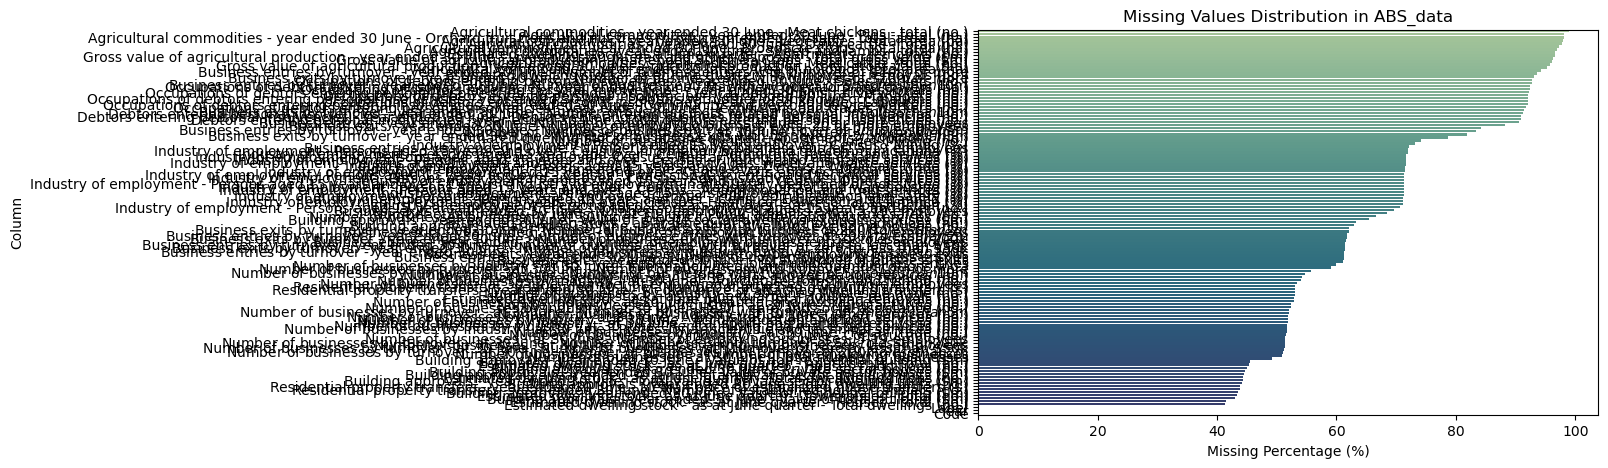

In [50]:
# The bar chart shows the proportion of the missing data.
plt.figure(figsize=(8, 5))
sns.barplot(
    data=missing.sort_values("missing_percent", ascending=False),
    x="missing_percent",
    y="column",
    palette="crest"
)
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Column")
plt.title("Missing Values Distribution in ABS_data")
plt.show()

C:\Users\ivini\AppData\Local\Temp\ipykernel_33000\2566202457.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


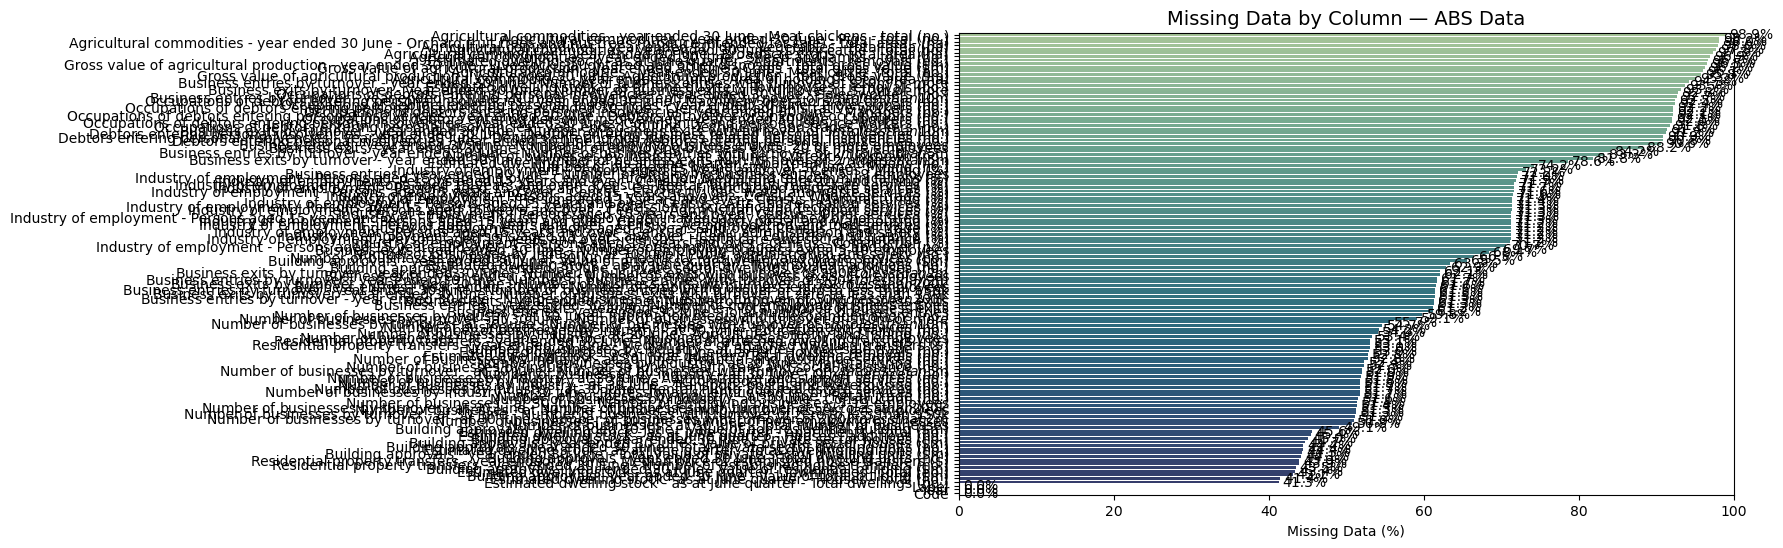

In [51]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=missing.sort_values("missing_percent", ascending=False),
    x="missing_percent",
    y="column",
    palette="crest"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.xlabel("Missing Data (%)")
plt.ylabel("")
plt.title("Missing Data by Column — ABS Data", fontsize=14)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

C:\Users\ivini\AppData\Local\Temp\ipykernel_33000\4069773445.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


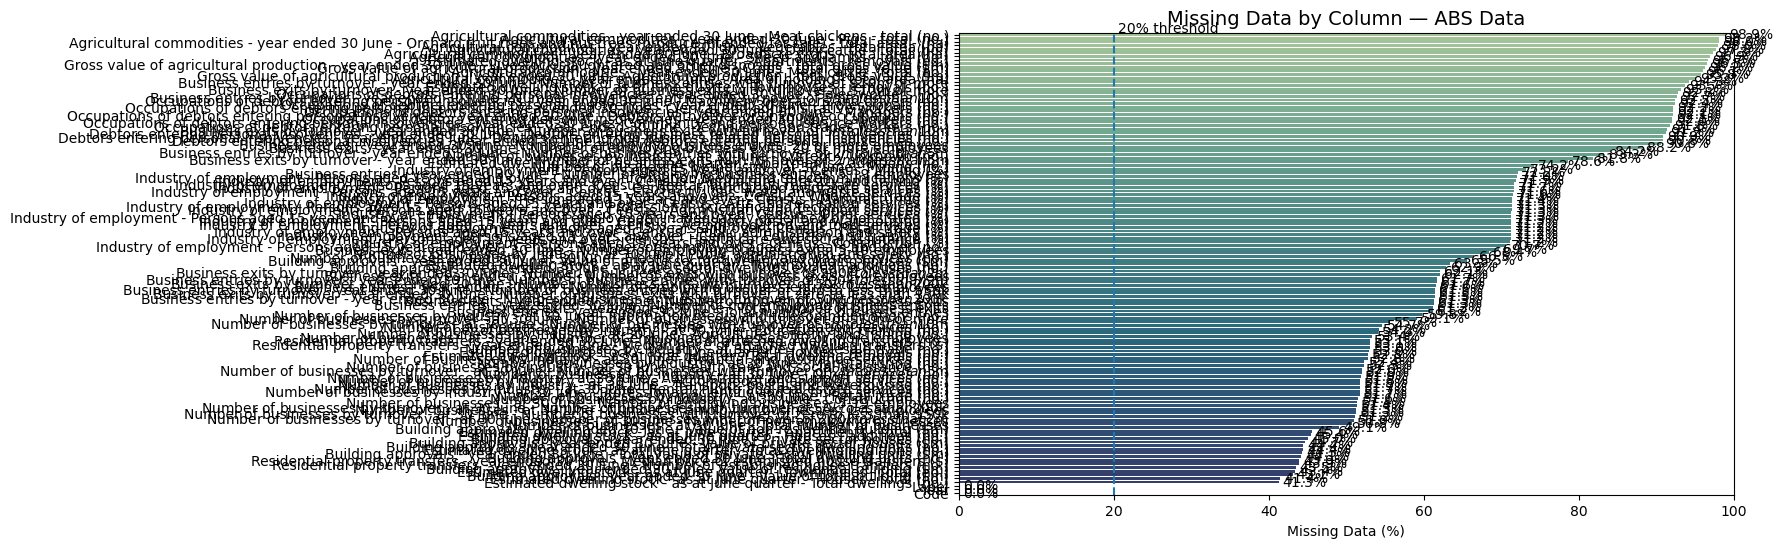

In [52]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=missing.sort_values("missing_percent", ascending=False),
    x="missing_percent",
    y="column",
    palette="crest"
)

plt.axvline(20, linestyle="--")
plt.text(20.5, -0.5, "20% threshold", fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.xlabel("Missing Data (%)")
plt.ylabel("")
plt.title("Missing Data by Column — ABS Data", fontsize=14)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

C:\Users\ivini\AppData\Local\Temp\ipykernel_33000\3070554157.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


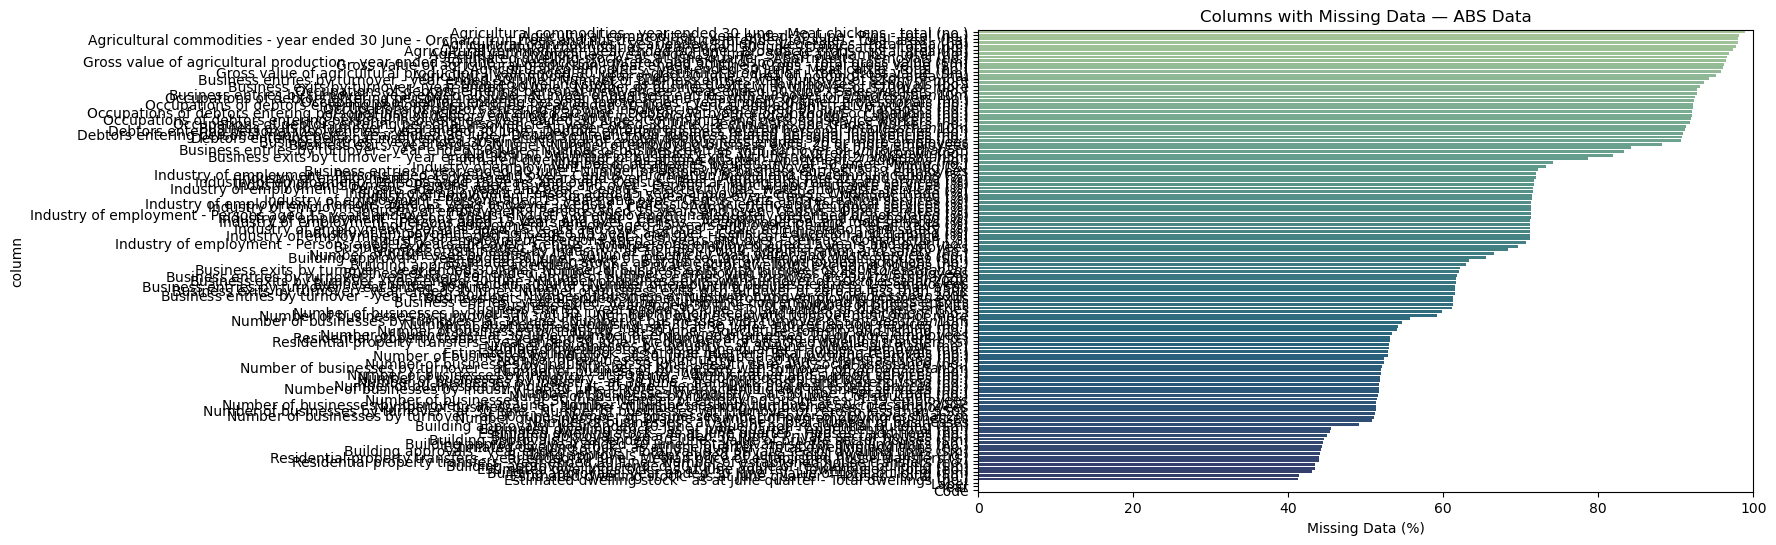

In [53]:
plot_data = missing[missing["missing_percent"] > 0]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data.sort_values("missing_percent", ascending=False),
    x="missing_percent",
    y="column",
    palette="crest"
)

plt.xlabel("Missing Data (%)")
plt.title("Columns with Missing Data — ABS Data")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

C:\Users\ivini\AppData\Local\Temp\ipykernel_33000\1662405379.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


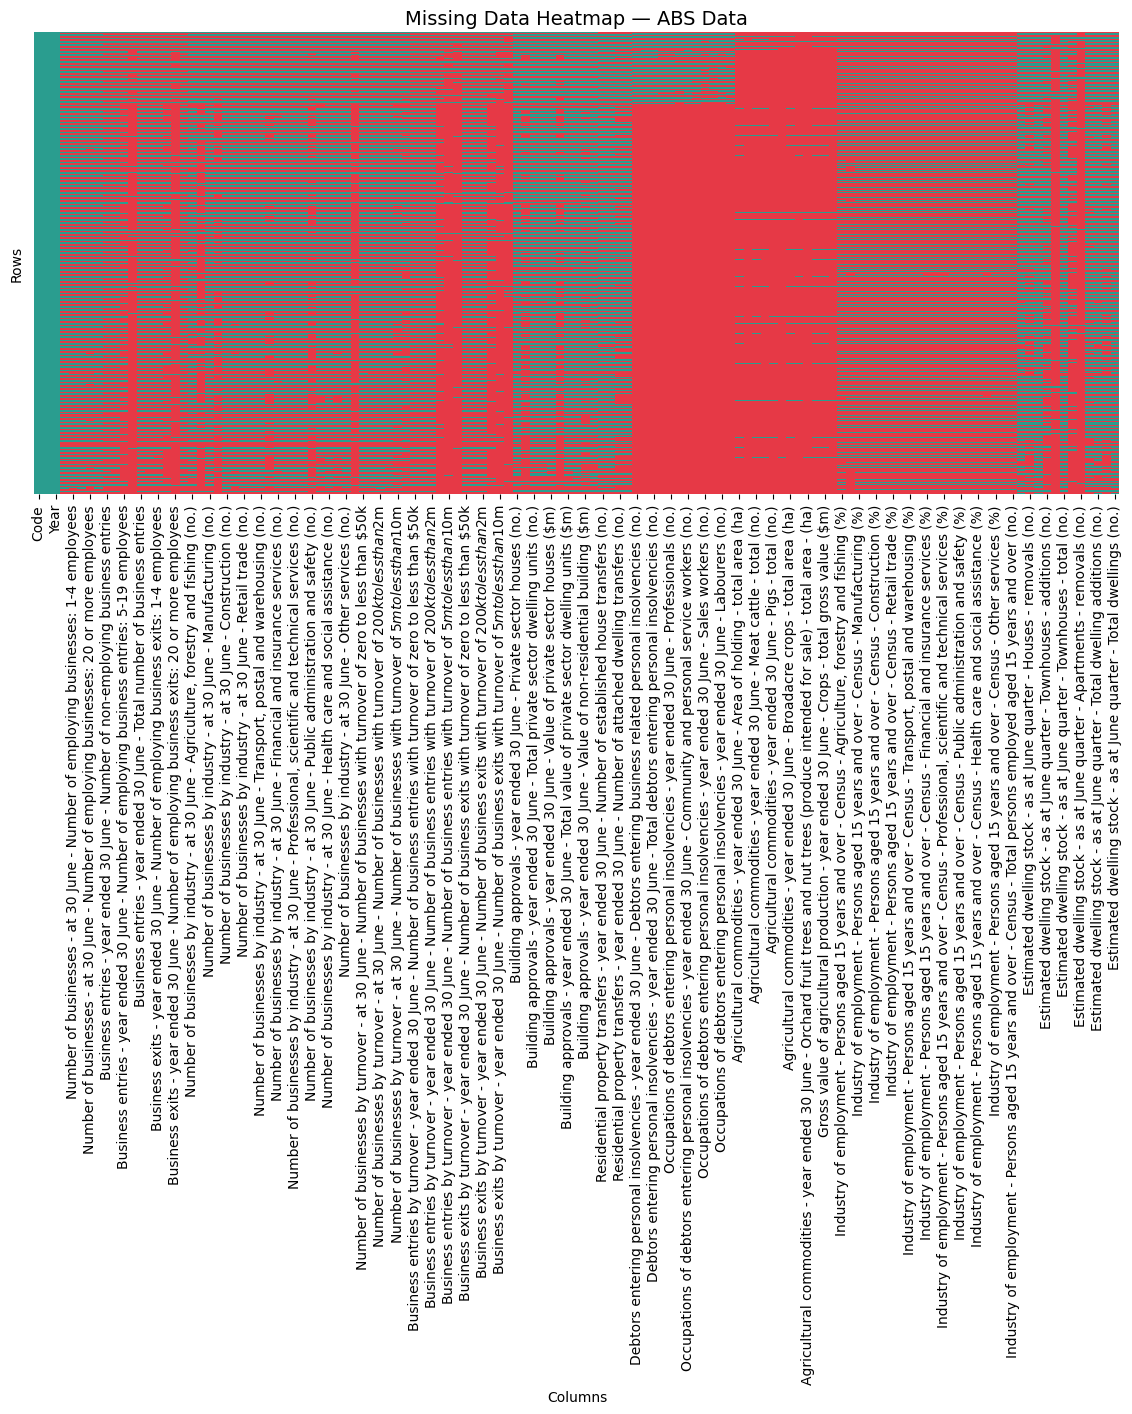

In [54]:
# Heatmap of missing value distribution (rows x columns)
plt.figure(figsize=(14, 6))
sns.heatmap(
    ABS_data.isna(),
    cbar=False,
    yticklabels=False,
    cmap=["#2a9d8f", "#e63946"]
)
plt.title("Missing Data Heatmap — ABS Data", fontsize=14)
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

C:\Users\ivini\AppData\Local\Temp\ipykernel_33000\3417726368.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


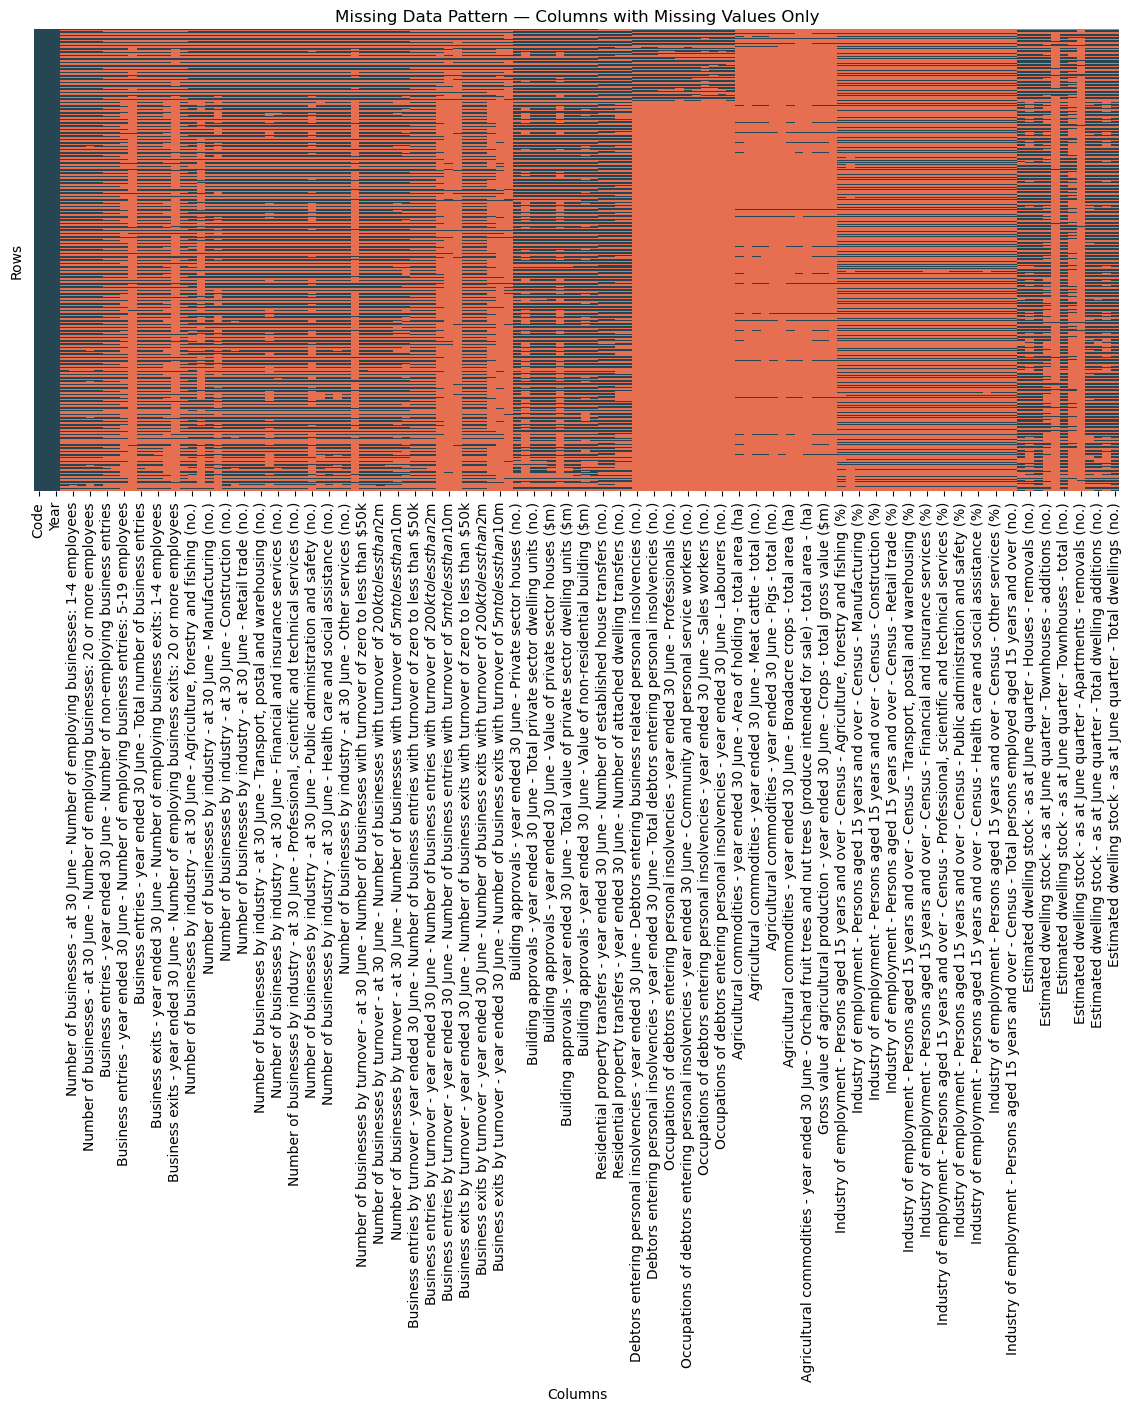

In [55]:
cols_with_missing = ABS_data.columns[ABS_data.isna().any()]

plt.figure(figsize=(14, 6))
sns.heatmap(
    ABS_data[cols_with_missing].isna(),
    cbar=False,
    yticklabels=False,
    cmap=["#264653", "#e76f51"]
)
plt.title("Missing Data Pattern — Columns with Missing Values Only")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

C:\Users\ivini\AppData\Local\Temp\ipykernel_33000\2401331934.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


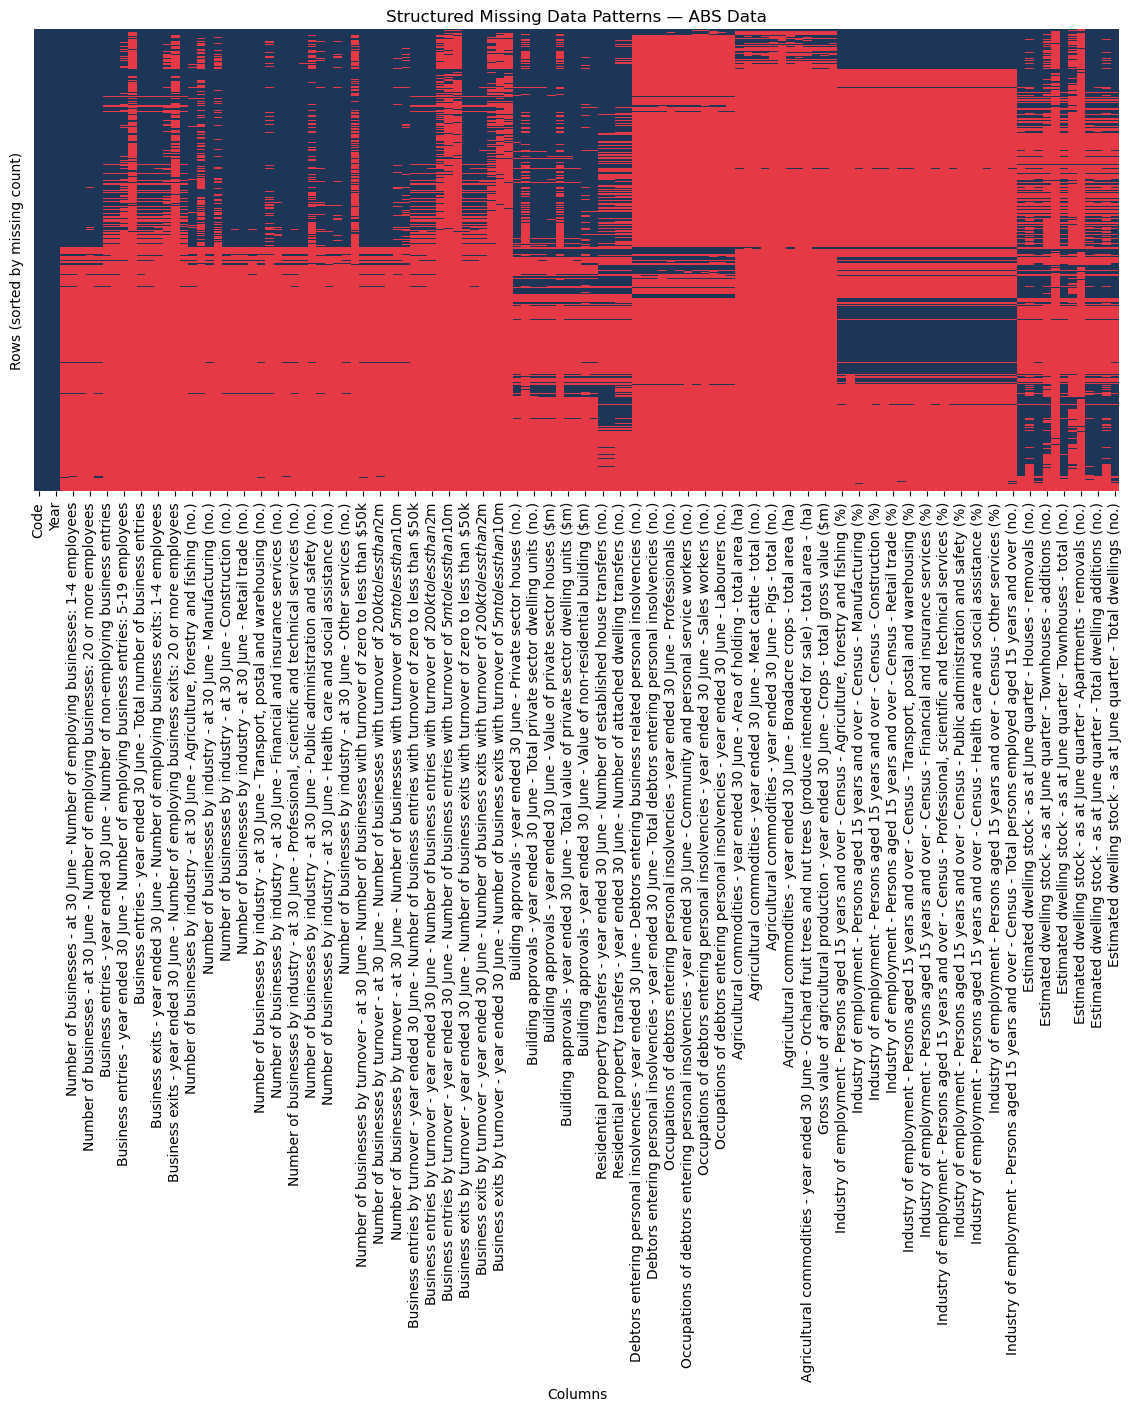

In [56]:
sorted_data = ABS_data[cols_with_missing].isna()
sorted_data = sorted_data.loc[sorted_data.sum(axis=1).sort_values().index]

plt.figure(figsize=(14, 6))
sns.heatmap(
    sorted_data,
    cbar=False,
    yticklabels=False,
    cmap=["#1d3557", "#e63946"]
)
plt.title("Structured Missing Data Patterns — ABS Data")
plt.xlabel("Columns")
plt.ylabel("Rows (sorted by missing count)")
plt.tight_layout()
plt.show()

In [57]:
#Deleted the columns with a missing ratio greater than 50%
missing_ratio = ABS_data.isna().mean() 
cols_to_drop = missing_ratio[missing_ratio > 0.50].index.tolist()
ABS_data = ABS_data.drop(columns=cols_to_drop)

In [58]:
ABS_data.head(5)

,Code,Label,Year,Building approvals - year ended 30 June - Private sector houses (no.),Building approvals - year ended 30 June - Total private sector dwelling units (no.),Building approvals - year ended 30 June - Total dwelling units (no.),Building approvals - year ended 30 June - Value of private sector houses ($m),Building approvals - year ended 30 June - Total value of private sector dwelling units ($m),Building approvals - year ended 30 June - Value of residential building ($m),Building approvals - year ended 30 June - Value of non-residential building ($m),Building approvals - year ended 30 June - Value of total building ($m),Residential property transfers - year ended 30 June - Number of established house transfers (no.),Residential property transfers - year ended 30 June - Median price of established house transfers ($),Estimated dwelling stock - as at June quarter - Houses - additions (no.),Estimated dwelling stock - as at June quarter - Houses - total (no.),Estimated dwelling stock - as at June quarter - Townhouses - total (no.),Estimated dwelling stock - as at June quarter - Apartments - total (no.),Estimated dwelling stock - as at June quarter - Total dwelling additions (no.),Estimated dwelling stock - as at June quarter - Total dwellings (no.)
7,AUS,Australia,2011,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
8,AUS,Australia,2016,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
9,AUS,Australia,2017,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,113258,7279135,1261457,1464325,218884,10022775
10,AUS,Australia,2018,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,319481,550000.0,113930,7371408,1293884,1530050,213652,10213246
11,AUS,Australia,2019,110689,185344,187751,42838,66887,69192,47331,116523,279464,545000.0,122142,7472853,1325743,1589770,215556,10406408


In [59]:
NGER_df=NGER_data
CER_df_powerStation=df_accredited
CER_df_project=df_committed_probable 
ABS_df=ABS_data

In [60]:
state_counts = NGER_data["State"].dropna().value_counts().reset_index()
state_counts.columns = ["State", "Count"]

In [61]:
state_counts_2 = df_accredited["State"].dropna().value_counts().reset_index()
state_counts_2.columns = ["State", "Count"]

## Data Exploration of NGER Dataset

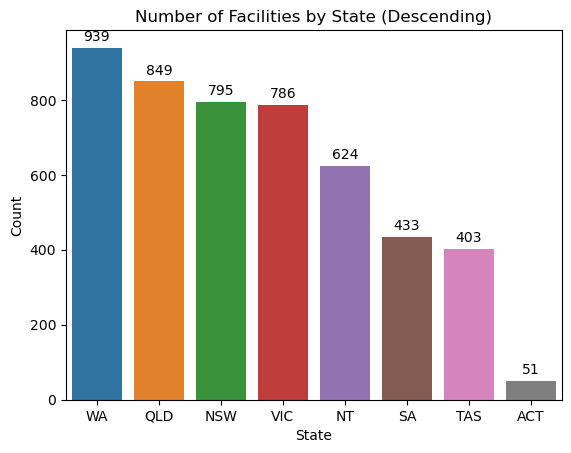

In [62]:
# explore NGER State data
ax = sns.barplot(
    data=state_counts,
    x="State",
    y="Count",
    order=state_counts["State"]  # ensures decreasing order
)

# Add value labels on top of bars
ax.bar_label(ax.containers[0], padding=3)

plt.title("Number of Facilities by State (Descending)")
plt.ylabel("Count")
plt.xlabel("State")
plt.show()

In [63]:
NGER_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5942 entries, 0 to 5941
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   source_dataset_id             5942 non-null   string 
 1   reporting_entity              5942 non-null   string 
 2   facility_name                 5942 non-null   string 
 3   type                          5936 non-null   string 
 4   State                         4880 non-null   string 
 5   electricity_production_gj     5938 non-null   Int32  
 6   electricity_production_mwh    5938 non-null   Int32  
 7   production_mwh_std            5938 non-null   float64
 8   scope1_tco2e                  3871 non-null   Int32  
 9   scope2_tco2e                  3871 non-null   Int32  
 10  total_emissions_tco2e         3871 non-null   Int32  
 11  emission_intensity_t_per_mwh  4830 non-null   float64
 12  grid_connected                4880 non-null   string 
 13  gri

In [64]:
NGER_data.shape

(5942, 16)

In [65]:
NGER_data.columns

Index(['source_dataset_id', 'reporting_entity', 'facility_name', 'type',
       'State', 'electricity_production_gj', 'electricity_production_mwh',
       'production_mwh_std', 'scope1_tco2e', 'scope2_tco2e',
       'total_emissions_tco2e', 'emission_intensity_t_per_mwh',
       'grid_connected', 'grid', 'primary_fuel', 'important_notes'],
      dtype='object')

In [66]:
NGER_data.dtypes

source_dataset_id               string[python]
reporting_entity                string[python]
facility_name                   string[python]
type                            string[python]
State                           string[python]
electricity_production_gj                Int32
electricity_production_mwh               Int32
production_mwh_std                     float64
scope1_tco2e                             Int32
scope2_tco2e                             Int32
total_emissions_tco2e                    Int32
emission_intensity_t_per_mwh           float64
grid_connected                  string[python]
grid                            string[python]
primary_fuel                    string[python]
important_notes                 string[python]
dtype: object

In [67]:
NGER_data['State'].value_counts()

State
WA     939
QLD    849
NSW    795
VIC    786
NT     624
SA     433
TAS    403
ACT     51
Name: count, dtype: Int64

In [68]:
NGER_data.head()

,source_dataset_id,reporting_entity,facility_name,type,State,electricity_production_gj,electricity_production_mwh,production_mwh_std,scope1_tco2e,scope2_tco2e,total_emissions_tco2e,emission_intensity_t_per_mwh,grid_connected,grid,primary_fuel,important_notes
0,ID0075,ACCIONA ENERGY OCEANIA PTY LTD,Gunning Wind Farm,F,NSW,567719,157700,157700.0,19,293,312,0.0,On,Nem,Wind,<NA>
1,ID0075,ACCIONA ENERGY OCEANIA PTY LTD,Royalla Solar Farm,F,ACT,213115,59199,59199.0,0,15,15,0.0,On,Nem,Solar,<NA>
2,ID0075,ACCIONA ENERGY OCEANIA PTY LTD,Waubra Wind Farm,F,VIC,2461803,683834,683834.0,77,1144,1221,0.0,On,Nem,Wind,<NA>
3,ID0075,ACCIONA ENERGY OCEANIA PTY LTD,Corporate Total,C,<NA>,3242637,900733,900733.0,96,1452,1548,NaN,<NA>,<NA>,<NA>,<NA>
4,ID0075,AGL ENERGY LIMITED,Banimboola Hydro,F,VIC,137094,38082,38082.0,5,17,22,0.0,On,Nem,Hydro,<NA>


In [69]:
NGER_missing = NGER_data.isnull().mean().sort_values(ascending=False) * 100

## Data Exploration of CER Dataset

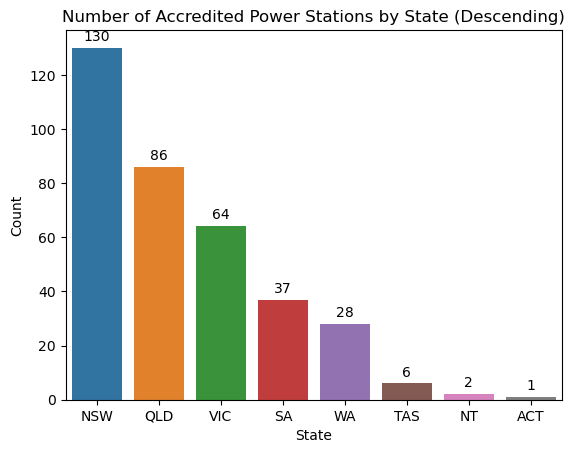

In [70]:
# Plot sorted bars
ax = sns.barplot(
    data=state_counts_2,
    x="State",
    y="Count",
    order=state_counts_2["State"]  # ensures descending order
)

# Add value labels on top of bars
ax.bar_label(ax.containers[0], padding=3)

plt.title("Number of Accredited Power Stations by State (Descending)")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

In [71]:
df_accredited.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Accreditation code        354 non-null    string        
 1   Power station name        354 non-null    string        
 2   State                     354 non-null    string        
 3   Postcode                  354 non-null    string        
 4   Mw Capacity               354 non-null    float64       
 5   Fuel Source               354 non-null    string        
 6   Accreditation start date  354 non-null    datetime64[ns]
 7   Approval date             354 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), string(5)
memory usage: 22.2 KB


In [72]:
df_committed_probable.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Project Name    97 non-null     string        
 1   State           97 non-null     string        
 2   Mw Capacity     97 non-null     float64       
 3   Fuel Source     97 non-null     string        
 4   Committed Date  33 non-null     datetime64[ns]
 5   status          97 non-null     string        
dtypes: datetime64[ns](1), float64(1), string(4)
memory usage: 4.7 KB


In [73]:
df_accredited.shape, df_committed_probable.shape

((354, 8), (97, 6))

In [74]:
df_committed_probable.columns

Index(['Project Name', 'State', 'Mw Capacity', 'Fuel Source', 'Committed Date',
       'status'],
      dtype='object')

In [75]:
df_accredited.columns

Index(['Accreditation code', 'Power station name', 'State', 'Postcode',
       'Mw Capacity', 'Fuel Source', 'Accreditation start date',
       'Approval date'],
      dtype='object')

In [76]:
df_accredited.dtypes

Accreditation code          string[python]
Power station name          string[python]
State                       string[python]
Postcode                    string[python]
Mw Capacity                        float64
Fuel Source                 string[python]
Accreditation start date    datetime64[ns]
Approval date               datetime64[ns]
dtype: object

In [77]:
df_committed_probable.dtypes

Project Name      string[python]
State             string[python]
Mw Capacity              float64
Fuel Source       string[python]
Committed Date    datetime64[ns]
status            string[python]
dtype: object

In [78]:
df_accredited.head()

,Accreditation code,Power station name,State,Postcode,Mw Capacity,Fuel Source,Accreditation start date,Approval date
0,SRPXQLE8,"Laura Johnson Home, Townview - Solar w SGU - QLD",QLD,4825,0.227,Solar,2024-10-15,2025-01-13
1,SRPYNS39,Leppington - Solar - NSW,NSW,2179,0.732,Solar,2024-11-22,2025-01-13
2,SRPYNS58,Quakers Hillside Care Community - Solar w SGU ...,NSW,2763,0.200,Solar,2024-12-19,2025-01-13
3,SRPXVCN4,Rest Nominees - Solar wSGU - VIC,VIC,3008,0.119,Solar,2024-09-20,2025-01-13
4,SRPXQLF9,Retail First Mt Ommaney-Solar-QLD,QLD,4074,1.000,Solar,2024-10-29,2025-01-13


In [79]:
df_committed_probable.head()

,Project Name,State,Mw Capacity,Fuel Source,Committed Date,status
0,East Rockingham Resource Recovery Facility,WA,29.0,Biomass,2019-12-01,committed
1,Mangalore Renewable Energy Project,VIC,5.0,Solar,2021-09-01,committed
2,Orange Community Renewable Energy Park,NSW,5.0,Solar,2022-07-01,committed
3,Moorebank Logistics Park,NSW,60.0,Solar,2022-09-01,committed
4,Kidston Pumped Hydro Storage Project,QLD,250.0,Hydro,2023-07-01,committed


In [80]:
DF_Accredited_missing = df_accredited.isnull().mean().sort_values(ascending=False) * 100
DF_Committed_Probable_missing = df_committed_probable.isnull().mean().sort_values(ascending=False) * 100

## Data Exploration of ABS Dataset

In [81]:
ABS_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29097 entries, 7 to 29103
Data columns (total 19 columns):
 #   Column                                                                                                 Non-Null Count  Dtype  
---  ------                                                                                                 --------------  -----  
 0   Code                                                                                                   29093 non-null  string 
 1   Label                                                                                                  29091 non-null  string 
 2   Year                                                                                                   29090 non-null  Int64  
 3   Building approvals - year ended 30 June - Private sector houses (no.)                                  15991 non-null  Int64  
 4   Building approvals - year ended 30 June - Total private sector dwelling units (no.)           

In [82]:
ABS_data.shape

(29097, 19)

In [83]:
ABS_data.columns

Index(['Code', 'Label', 'Year',
       'Building approvals - year ended 30 June - Private sector houses (no.)',
       'Building approvals - year ended 30 June - Total private sector dwelling units (no.)',
       'Building approvals - year ended 30 June - Total dwelling units (no.)',
       'Building approvals - year ended 30 June - Value of private sector houses ($m)',
       'Building approvals - year ended 30 June - Total value of private sector dwelling units ($m)',
       'Building approvals - year ended 30 June - Value of residential building ($m)',
       'Building approvals - year ended 30 June - Value of non-residential building ($m)',
       'Building approvals - year ended 30 June - Value of total building ($m)',
       'Residential property transfers - year ended 30 June - Number of established house transfers (no.)',
       'Residential property transfers - year ended 30 June - Median price of established house transfers ($)',
       'Estimated dwelling stock - as at June 

In [84]:
ABS_data.dtypes

Code                                                                                                     string[python]
Label                                                                                                    string[python]
Year                                                                                                              Int64
Building approvals - year ended 30 June - Private sector houses (no.)                                             Int64
Building approvals - year ended 30 June - Total private sector dwelling units (no.)                               Int64
Building approvals - year ended 30 June - Total dwelling units (no.)                                              Int64
Building approvals - year ended 30 June - Value of private sector houses ($m)                                     Int64
Building approvals - year ended 30 June - Total value of private sector dwelling units ($m)                       Int64
Building approvals - year ended 30 June 

In [85]:
df_accredited['Fuel Source'].value_counts()

Fuel Source
Solar                                                347
Wind                                                   3
Sewage Gas and Biomass-Based Components of Sewage      1
Agricultural Waste                                     1
Landfill Gas                                           1
Biomass-Based Components of Municipal Solid Waste      1
Name: count, dtype: Int64

In [86]:
ABS_data.head()

,Code,Label,Year,Building approvals - year ended 30 June - Private sector houses (no.),Building approvals - year ended 30 June - Total private sector dwelling units (no.),Building approvals - year ended 30 June - Total dwelling units (no.),Building approvals - year ended 30 June - Value of private sector houses ($m),Building approvals - year ended 30 June - Total value of private sector dwelling units ($m),Building approvals - year ended 30 June - Value of residential building ($m),Building approvals - year ended 30 June - Value of non-residential building ($m),Building approvals - year ended 30 June - Value of total building ($m),Residential property transfers - year ended 30 June - Number of established house transfers (no.),Residential property transfers - year ended 30 June - Median price of established house transfers ($),Estimated dwelling stock - as at June quarter - Houses - additions (no.),Estimated dwelling stock - as at June quarter - Houses - total (no.),Estimated dwelling stock - as at June quarter - Townhouses - total (no.),Estimated dwelling stock - as at June quarter - Apartments - total (no.),Estimated dwelling stock - as at June quarter - Total dwelling additions (no.),Estimated dwelling stock - as at June quarter - Total dwellings (no.)
7,AUS,Australia,2011,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
8,AUS,Australia,2016,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
9,AUS,Australia,2017,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,113258,7279135,1261457,1464325,218884,10022775
10,AUS,Australia,2018,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,319481,550000.0,113930,7371408,1293884,1530050,213652,10213246
11,AUS,Australia,2019,110689,185344,187751,42838,66887,69192,47331,116523,279464,545000.0,122142,7472853,1325743,1589770,215556,10406408


In [87]:
ABS_missing = ABS_data.isnull().mean().sort_values(ascending=False) * 100

## Joining the data

In [88]:
def normalize_name(s):
    if pd.isna(s):
        return ""
    return str(s).strip().lower().replace("  ", " ").replace(".", "").replace("-", " ")

NGER_data['facility_name_norm'] = NGER_data['facility_name'].apply(normalize_name)
df_accredited['facility_name_norm'] = df_accredited['Power station name'].apply(normalize_name)
df_committed_probable['facility_name_norm'] = df_committed_probable['Project Name'].apply(normalize_name)

In [89]:
NGER_data.columns, df_accredited.columns, df_committed_probable.columns, ABS_data.columns

(Index(['source_dataset_id', 'reporting_entity', 'facility_name', 'type',
        'State', 'electricity_production_gj', 'electricity_production_mwh',
        'production_mwh_std', 'scope1_tco2e', 'scope2_tco2e',
        'total_emissions_tco2e', 'emission_intensity_t_per_mwh',
        'grid_connected', 'grid', 'primary_fuel', 'important_notes',
        'facility_name_norm'],
       dtype='object'),
 Index(['Accreditation code', 'Power station name', 'State', 'Postcode',
        'Mw Capacity', 'Fuel Source', 'Accreditation start date',
        'Approval date', 'facility_name_norm'],
       dtype='object'),
 Index(['Project Name', 'State', 'Mw Capacity', 'Fuel Source', 'Committed Date',
        'status', 'facility_name_norm'],
       dtype='object'),
 Index(['Code', 'Label', 'Year',
        'Building approvals - year ended 30 June - Private sector houses (no.)',
        'Building approvals - year ended 30 June - Total private sector dwelling units (no.)',
        'Building approvals - yea

In [90]:
merged_facilities = pd.merge(
    NGER_data,
    df_accredited,
    left_on=['facility_name_norm', 'State'],
    right_on=['facility_name_norm', 'State'],
    how='outer',
    suffixes=('_NGER', '_CER')
)

In [91]:
merged_facilities = pd.merge(
    merged_facilities,
    df_committed_probable,
    left_on=['facility_name_norm', 'State'],
    right_on=['facility_name_norm', 'State'],
    how='outer',
    suffixes=('', '_Committed')
)

In [92]:
CER_df_powerStation.to_csv("CER_df_powerStation.csv", index=False)
# Copy the original DataFrame
df = CER_df_powerStation.copy() 

In [93]:
print("Dataset shape: ", df.shape)
print("All column names: ", list(df.columns))
display(df.head(3))

# Candidate column name mappings for different features
CANDS = {
    "name":     ["Facility Name","Station Name","Name","Power Station","PowerStation","facility_name"],
    "state":    ["State","state","State/Territory","Jurisdiction"],
    "suburb":   ["Suburb","City","Town","Locality","suburb"],
    "postcode": ["Postcode","postcode","Postal Code","ZIP","zip"],
    "address":  ["Address","Street Address","Site Address","location","Location"],
}

# Candidate column names for latitude/longitude
LAT_CANDS = ["lat","latitude","Latitude","LAT"]
LON_CANDS = ["lon","lng","longitude","Longitude","LON","LNG"]

# Function to pick the first matching column from candidate list
def pick(df, options):
    for c in options:
        if c in df.columns:
            return c
    return None

# Detect usable columns from candidates
picks = {k: pick(df, v) for k,v in CANDS.items()}
picks["lat"] = pick(df, LAT_CANDS)
picks["lon"] = pick(df, LON_CANDS)
print("\nAuto-detected column matches: ", picks)

# Check missing value rate
for k, c in picks.items():
    if c:
        miss = df[c].isna().mean()
        print(f"{k:8s} -> {c:20s} missing rate: {miss:.1%}")

# Function to build query string from selected columns      
def make_query(row):
    parts = []
    for key in ["address","name","suburb","state","postcode"]:
        col = picks.get(key)
        if col and pd.notna(row[col]):
            parts.append(str(row[col]).strip())
    parts.append("Australia")
    return ", ".join([p for p in parts if p])

sample = df.head(10).copy()
sample["query_preview"] = sample.apply(make_query, axis=1)
cols_show = [picks.get("name"), picks.get("suburb"), picks.get("state"),
             picks.get("postcode"), picks.get("address"), "query_preview"]
display(sample[ [c for c in cols_show if c] ])

Dataset shape:  (354, 9)
All column names:  ['Accreditation code', 'Power station name', 'State', 'Postcode', 'Mw Capacity', 'Fuel Source', 'Accreditation start date', 'Approval date', 'facility_name_norm']


,Accreditation code,Power station name,State,Postcode,Mw Capacity,Fuel Source,Accreditation start date,Approval date,facility_name_norm
0,SRPXQLE8,"Laura Johnson Home, Townview - Solar w SGU - QLD",QLD,4825,0.227,Solar,2024-10-15,2025-01-13,"laura johnson home, townview solar w sgu qld"
1,SRPYNS39,Leppington - Solar - NSW,NSW,2179,0.732,Solar,2024-11-22,2025-01-13,leppington solar nsw
2,SRPYNS58,Quakers Hillside Care Community - Solar w SGU ...,NSW,2763,0.200,Solar,2024-12-19,2025-01-13,quakers hillside care community solar w sgu ...



Auto-detected column matches:  {'name': None, 'state': 'State', 'suburb': None, 'postcode': 'Postcode', 'address': None, 'lat': None, 'lon': None}
state    -> State                missing rate: 0.0%
postcode -> Postcode             missing rate: 0.0%


,State,Postcode,query_preview
0,QLD,4825,"QLD, 4825, Australia"
1,NSW,2179,"NSW, 2179, Australia"
2,NSW,2763,"NSW, 2763, Australia"
3,VIC,3008,"VIC, 3008, Australia"
4,QLD,4074,"QLD, 4074, Australia"
5,QLD,4110,"QLD, 4110, Australia"
6,TAS,7249,"TAS, 7249, Australia"
7,SA,5113,"SA, 5113, Australia"
8,NSW,2092,"NSW, 2092, Australia"
9,SA,5106,"SA, 5106, Australia"


In [94]:
# Parameters
USER_AGENT  = "Vinit"   
COUNTRY     = "Australia"
CACHE_FILE  = "postcode_cache.jsonl"

# State bounding boxes: (min_Lon, min_Lat, max_Lon, max_Lat)
STATE_VIEWBOX = {
    "NSW": (141.0, -37.6, 153.7, -28.0),
    "VIC": (141.0, -39.5, 150.0, -33.5),
    "QLD": (138.0, -29.5, 153.7, -10.5),
    "SA" : (129.0, -38.2, 141.5, -25.0),
    "WA" : (112.9, -35.5, 129.0, -13.5),
    "TAS": (144.0, -44.1, 149.5, -39.0),
    "NT" : (129.0, -26.0, 138.0, -10.0),
    "ACT": (148.7, -35.8, 149.4, -35.1),
}

# Return bounding box points for a given state (geopy Point(lat, lon))
def _vb_points(state):
    vb = STATE_VIEWBOX.get(state)
    if not vb: return None
    min_lon, min_lat, max_lon, max_lat = vb
    return [Point(min_lat, min_lon), Point(max_lat, max_lon)]  # geopy 需要 (lat, lon)

# Load cache file
def _load_cache(path=CACHE_FILE):
    cache={}
    if os.path.exists(path):
        with open(path,"r",encoding="utf-8") as f:
            for line in f:
                try:
                    obj=json.loads(line); cache[obj["key"]]=obj
                except: pass
    return cache
    
# Save cache file
def _save_cache(obj, path=CACHE_FILE):
    with open(path,"a",encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False)+"\n")

# 1) Clean & Deduplicate (State, Postcode)
df = CER_df_powerStation.copy()  
STATE_COL, POSTCODE_COL = "State", "Postcode"

# Clean state column (uppercase, strip spaces)
df["State_clean"] = df[STATE_COL].astype(str).str.upper().str.strip()

# Clean postcode column (extract 4-digit, pad with zeros)
df["Postcode_clean"] = df[POSTCODE_COL].astype(str).str.extract(r"(\d{1,4})")[0].str.zfill(4)

# Create combined key (State|Postcode)
df["_sp"] = df["State_clean"] + "|" + df["Postcode_clean"]

# Get unique (State, Postcode) pairs
pairs = df[["_sp","State_clean","Postcode_clean"]].drop_duplicates().reset_index(drop=True)
print("Number of unique (State, Postcode) pairs: ", len(pairs))

# 2) (State, Postcode) -> Coordinates (postcode centroid)

# Initialize geolocator with user agent and rate limiter
geolocator = Nominatim(user_agent=USER_AGENT, timeout=10)
geocode    = RateLimiter(geolocator.geocode, min_delay_seconds=1.1, swallow_exceptions=True)

# Load cached results
cache = _load_cache()
out = {} 

# Iterate through all unique (State, Postcode) pairs
for _, r in tqdm(pairs.iterrows(), total=len(pairs), desc="Geocoding postcode centroids"):
    key   = r["_sp"]
    state = r["State_clean"]
    pc    = r["Postcode_clean"]

    if key in cache:
        out[key] = cache[key]; continue

    # L1: Try geocoding with {postcode, state, country} + state bounding box + country_codes='au'
    kwargs = dict(exactly_one=True, addressdetails=True, country_codes="au")
    vb_pts = _vb_points(state)
    if vb_pts: kwargs.update(viewbox=vb_pts, bounded=True)

    loc = geocode({"postalcode": pc, "state": state, "country": COUNTRY}, **kwargs)

    # L2: Fallback - only {postcode, country} (still postcode centroid)
    if loc is None:
        loc = geocode({"postalcode": pc, "country": COUNTRY},
                      exactly_one=True, addressdetails=True, country_codes="au")
        
    # Save result object
    if loc:
        obj = {
            "key": key, "state": state, "postcode": pc,
            "lat": float(loc.latitude), "lon": float(loc.longitude),
            "source": "nominatim:postcode-centroid",
            "display_name": loc.raw.get("display_name","")
        }
    else:
        obj = {"key": key, "state": state, "postcode": pc,
               "lat": None, "lon": None, "source": "unresolved", "display_name": ""}

    _save_cache(obj); out[key] = obj
    
# Convert results to DataFrame
postcode_geo = pd.DataFrame(list(out.values()))

# Create combined key (State|Postcode)
postcode_geo["_sp"] = postcode_geo["state"] + "|" + postcode_geo["postcode"]

# Ensure unique keys (no duplicates)
assert postcode_geo["_sp"].is_unique, "Duplicate (State, Postcode) found, please check."

# Print summary of successful geocoding
print(f"Postcode centroid geocoding success: {(postcode_geo['lat'].notna().sum())}/{len(postcode_geo)}")

# 3) Merge geocoded dataframe 
merged = df.merge(
    postcode_geo[["_sp","lat","lon","source","display_name"]],
    on="_sp", how="left"
).copy()

# Standardize final output columns
merged["latitude_final"]  = merged["lat"]
merged["longitude_final"] = merged["lon"]
merged["geo_source"]      = merged["source"]
merged["geo_granularity"] = "postcode"

# 4) Validation checks
print("Row count (original vs merged):", len(df), len(merged))
assert len(df) == len(merged), "Row count mismatch after merge!"

# Count how many rows still have missing coordinates
miss = merged[["latitude_final","longitude_final"]].isna().any(axis=1).sum()
print("Records with missing coordinates:", miss)
assert miss == 0, "There are still rows with missing coordinates!"

# Australia rough bounding box sanity check
in_range = merged["latitude_final"].between(-44, -10) & merged["longitude_final"].between(112, 154)
print("Outside-AU-bounds count:", (~in_range).sum())
assert in_range.all(), "Some coordinates fall outside Australia bounds!"

Number of unique (State, Postcode) pairs:  251


Geocoding postcode centroids:   0%|          | 0/251 [00:00<?, ?it/s]

Postcode centroid geocoding success: 251/251
Row count (original vs merged): 354 354
Records with missing coordinates: 0
Outside-AU-bounds count: 0


In [95]:
# 1) Key indicators
N_total   = len(merged)
N_pairs   = len(postcode_geo)

# Coverage: proportion of rows with both latitude and longitude
coverage  = merged[["latitude_final","longitude_final"]].notna().all(axis=1).mean()

# Source distribution counts
src_counts = merged["geo_source"].value_counts(dropna=False)

# Granularity distribution
gran_counts = merged["geo_granularity"].value_counts(dropna=False) if "geo_granularity" in merged.columns else pd.Series()

print("=== Data Augmentation Summary ===")
print(f"Total records: {N_total}")
print(f"Unique (State, Postcode) pairs: {N_pairs}")
print(f"Coordinate coverage: {coverage:.1%}")

print("Source distribution (geo_source):")
display(src_counts.to_frame("count"))

if not gran_counts.empty:
    print("\nGranularity distribution (geo_granularity):")
    display(gran_counts.to_frame("count"))

# 2) Overview by state
by_state = (merged
    .groupby(merged["State"].astype(str).str.upper().str.strip())
    .agg(
        n=("State","size"),
        n_postcodes=("Postcode", lambda s: pd.Series(s).astype(str).str.extract(r"(\d{1,4})")[0].str.zfill(4).nunique()),
        lat_mean=("latitude_final","mean"),
        lon_mean=("longitude_final","mean")
    )
    .sort_values("n", ascending=False)
)
print("\nUnique postcode counts per state:")
display(by_state)

# 3) Example preview
cols_show = ["Power station name","State","Postcode","latitude_final","longitude_final","geo_source"]
cols_show = [c for c in cols_show if c in merged.columns]
print("\nRandom preview of 10 records:")
display(merged.sample(10, random_state=42)[cols_show])

=== Data Augmentation Summary ===
Total records: 354
Unique (State, Postcode) pairs: 251
Coordinate coverage: 100.0%
Source distribution (geo_source):


,count
geo_source,
nominatim:postcode-centroid,354



Granularity distribution (geo_granularity):


,count
geo_granularity,
postcode,354



Unique postcode counts per state:


,n,n_postcodes,lat_mean,lon_mean
State,,,,
NSW,130,88,-33.521038,150.391404
QLD,86,54,-25.145643,151.116524
VIC,64,49,-37.608062,144.921516
SA,37,31,-34.789312,138.828519
WA,28,21,-30.114169,116.781746
TAS,6,6,-42.372227,147.132850
NT,2,1,-12.498406,130.980495
ACT,1,1,-35.595178,149.209594



Random preview of 10 records:


,Power station name,State,Postcode,latitude_final,longitude_final,geo_source
220,Bunnings Hoppers Crossing - Solar - VIC,VIC,3029,-37.844671,144.702070,nominatim:postcode-centroid
42,BAE Williamtown - Solar - NSW,NSW,2318,-32.764001,151.876441,nominatim:postcode-centroid
286,Clyde Office and Warehouse - Solar w SGU - NSW,NSW,2142,-33.829490,151.013414,nominatim:postcode-centroid
181,Cherry Lane - Solar - VIC,VIC,3026,-37.807419,144.778739,nominatim:postcode-centroid
56,OZLEMFOODSWA-SOLAR w SGU-QLD,QLD,4207,-27.787745,153.152049,nominatim:postcode-centroid
272,Harbourside Townsville - Solar w SGU - QLD,QLD,4810,-19.242267,146.791292,nominatim:postcode-centroid
15,Lai Industries - Solar w SGU - SA,SA,5010,-34.864606,138.570510,nominatim:postcode-centroid
57,Somerville Gardens Care Community - Solar w SG...,VIC,3912,-38.206564,145.218718,nominatim:postcode-centroid
140,Armadale Shopping Centre 700kW - Solar - WA,WA,6112,-32.141972,115.999612,nominatim:postcode-centroid
335,Bunnings Sunshine - Solar - VIC,VIC,3020,-37.774379,144.833549,nominatim:postcode-centroid


In [96]:
# Create a base map centered roughly on Australia (lat, lon) with a country-level zoom
m = folium.Map(location=[-25.27, 133.77], zoom_start=4)

# Add markers with tooltips
for _, r in merged.iterrows():
    if pd.notna(r["latitude_final"]) and pd.notna(r["longitude_final"]):
        folium.CircleMarker(
            location=[r["latitude_final"], r["longitude_final"]],
            radius=3,
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
            tooltip=r.get("Power station name", "Unknown")  # Hover label
        ).add_to(m)

# Display the map
m

## Merging the datasets

In [106]:
NGER_df.columns

Index(['source_dataset_id', 'reporting_entity', 'facility_name', 'type',
       'State', 'electricity_production_gj', 'electricity_production_mwh',
       'production_mwh_std', 'scope1_tco2e', 'scope2_tco2e',
       'total_emissions_tco2e', 'emission_intensity_t_per_mwh',
       'grid_connected', 'grid', 'primary_fuel', 'important_notes',
       'facility_name_norm'],
      dtype='object')

In [107]:
CER_df_powerStation.columns

Index(['Accreditation code', 'Power station name', 'State', 'Postcode',
       'Mw Capacity', 'Fuel Source', 'Accreditation start date',
       'Approval date', 'facility_name_norm'],
      dtype='object')

In [108]:
CER_df_project.columns

Index(['Project Name', 'State', 'Mw Capacity', 'Fuel Source', 'Committed Date',
       'status', 'facility_name_norm'],
      dtype='object')

In [109]:
ABS_df.columns

Index(['Code', 'Label', 'Year',
       'Building approvals - year ended 30 June - Private sector houses (no.)',
       'Building approvals - year ended 30 June - Total private sector dwelling units (no.)',
       'Building approvals - year ended 30 June - Total dwelling units (no.)',
       'Building approvals - year ended 30 June - Value of private sector houses ($m)',
       'Building approvals - year ended 30 June - Total value of private sector dwelling units ($m)',
       'Building approvals - year ended 30 June - Value of residential building ($m)',
       'Building approvals - year ended 30 June - Value of non-residential building ($m)',
       'Building approvals - year ended 30 June - Value of total building ($m)',
       'Residential property transfers - year ended 30 June - Number of established house transfers (no.)',
       'Residential property transfers - year ended 30 June - Median price of established house transfers ($)',
       'Estimated dwelling stock - as at June 

In [114]:
NGER_df.to_excel('NGER Data.xlsx', index=False)

C:\Users\ivini\AppData\Local\Temp\ipykernel_33000\2458739438.py:1: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  NGER_df.to_excel('NGER Data.xlsx', index=False)


In [115]:
CER_df_powerStation.to_excel('CER Data 1.xlsx', index=False)

C:\Users\ivini\AppData\Local\Temp\ipykernel_33000\416050244.py:1: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  CER_df_powerStation.to_excel('CER Data 1.xlsx', index=False)


In [116]:
CER_df_project.to_excel('CER Data 2.xlsx', index=False)

C:\Users\ivini\AppData\Local\Temp\ipykernel_33000\3639894227.py:1: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  CER_df_project.to_excel('CER Data 2.xlsx', index=False)


In [117]:
ABS_df.to_excel('ABS Data.xlsx', index=False)

C:\Users\ivini\AppData\Local\Temp\ipykernel_33000\554792562.py:1: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  ABS_df.to_excel('ABS Data.xlsx', index=False)
